# 量子开放系统课程汇报：张量网络第一部分

## 奇异值分解的两种理解

$$
A = U\Sigma V^	op = \sum_{i=1}^{r}\sigma_i u_i v_i^	op,
\qquad
\sigma_1 \ge \sigma_2 \ge \cdots \ge 0
$$

奇异值分解可以从两个互补的角度理解：

1. 几何理解：$V^	op 	o \Sigma 	o U$
2. 近似理解：保留前 $k$ 个奇异值得到最优 rank-$k$ 近似


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from scipy.linalg import svd
from PIL import Image
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Arial Unicode MS",
    "DejaVu Sans",
]

## SVD 分解

$$
A_{m\times n}=U_{m\times m}\,\Sigma_{m\times n}\,V^\dagger_{n\times n},
\qquad
UU^\dagger=I_{m\times m},
\qquad
VV^\dagger=I_{n\times n}
$$

$$
\Sigma_{m\times n}\ \text{为对角阵，对角元称奇异值}
$$

1. 奇异值为非负实数；
2. 奇异值按降序排列。

$$
\Sigma=
\begin{pmatrix}
\sigma_1 & & & \\
& \sigma_2 & & \\
& & \ddots & \\
& & & \sigma_r
\end{pmatrix}
$$

$$
\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r > 0,
\qquad
r=\operatorname{rank}(A)
$$

当 $r<\min(m,n)$ 时，其余奇异值为 $0$。


## 例：一个 $2\times 3$ 矩阵

取

$$
A=
\begin{bmatrix}
3 & 2 & 2\\
2 & 3 & -2
\end{bmatrix}
$$

其 reduced SVD 为

$$
A = U\Sigma V^\top,
\qquad
U\in\mathbb{R}^{2\times 2},\quad
\Sigma\in\mathbb{R}^{2\times 2},\quad
V^\top\in\mathbb{R}^{2\times 3}
$$


In [2]:
A = np.array([
    [3.0, 2.0,  2.0],
    [2.0, 3.0, -2.0],
])

U_A, s_A, Vt_A = np.linalg.svd(A, full_matrices=False)
Sigma_A = np.diag(s_A)

print("A =")
print(A)
print("\nU shape =", U_A.shape)
print("Sigma shape =", Sigma_A.shape)
print("V^T shape =", Vt_A.shape)
print("\n奇异值 =", s_A)
print("\n重构误差 ||A-UΣV^T|| =", np.linalg.norm(A - U_A @ Sigma_A @ Vt_A))

A =
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

U shape = (2, 2)
Sigma shape = (2, 2)
V^T shape = (2, 3)

奇异值 = [5. 3.]

重构误差 ||A-UΣV^T|| = 1.041481514324134e-15


补充说明：若 $A\in\mathbb{R}^{m\times n}$ 的秩为 $r$，则 reduced SVD 写成

$$
A = U\Sigma V^\top,
\qquad
U\in\mathbb{R}^{m\times r},\quad
\Sigma\in\mathbb{R}^{r\times r},\quad
V\in\mathbb{R}^{n\times r}
$$

其中 $r=\operatorname{rank}(A)$，非零奇异值的个数恰等于矩阵的秩。对上面的例子，

$$
r=2,
\qquad
\sigma_1=5,
\quad
\sigma_2=3
$$

因此该矩阵是满行秩矩阵，但不是方阵。


## 理解一：几何分解

对于方阵变换

$$
M = U\Sigma V^\top
$$

可以分三步理解：

1. $V^\top$：将 right singular vectors 旋转到标准基方向
2. $\Sigma$：沿标准坐标轴拉伸或压缩；若某个 $\sigma_i=0$，则对应方向被压缩到零
3. $U$：将标准基再旋转到 left singular vectors 对应的方向


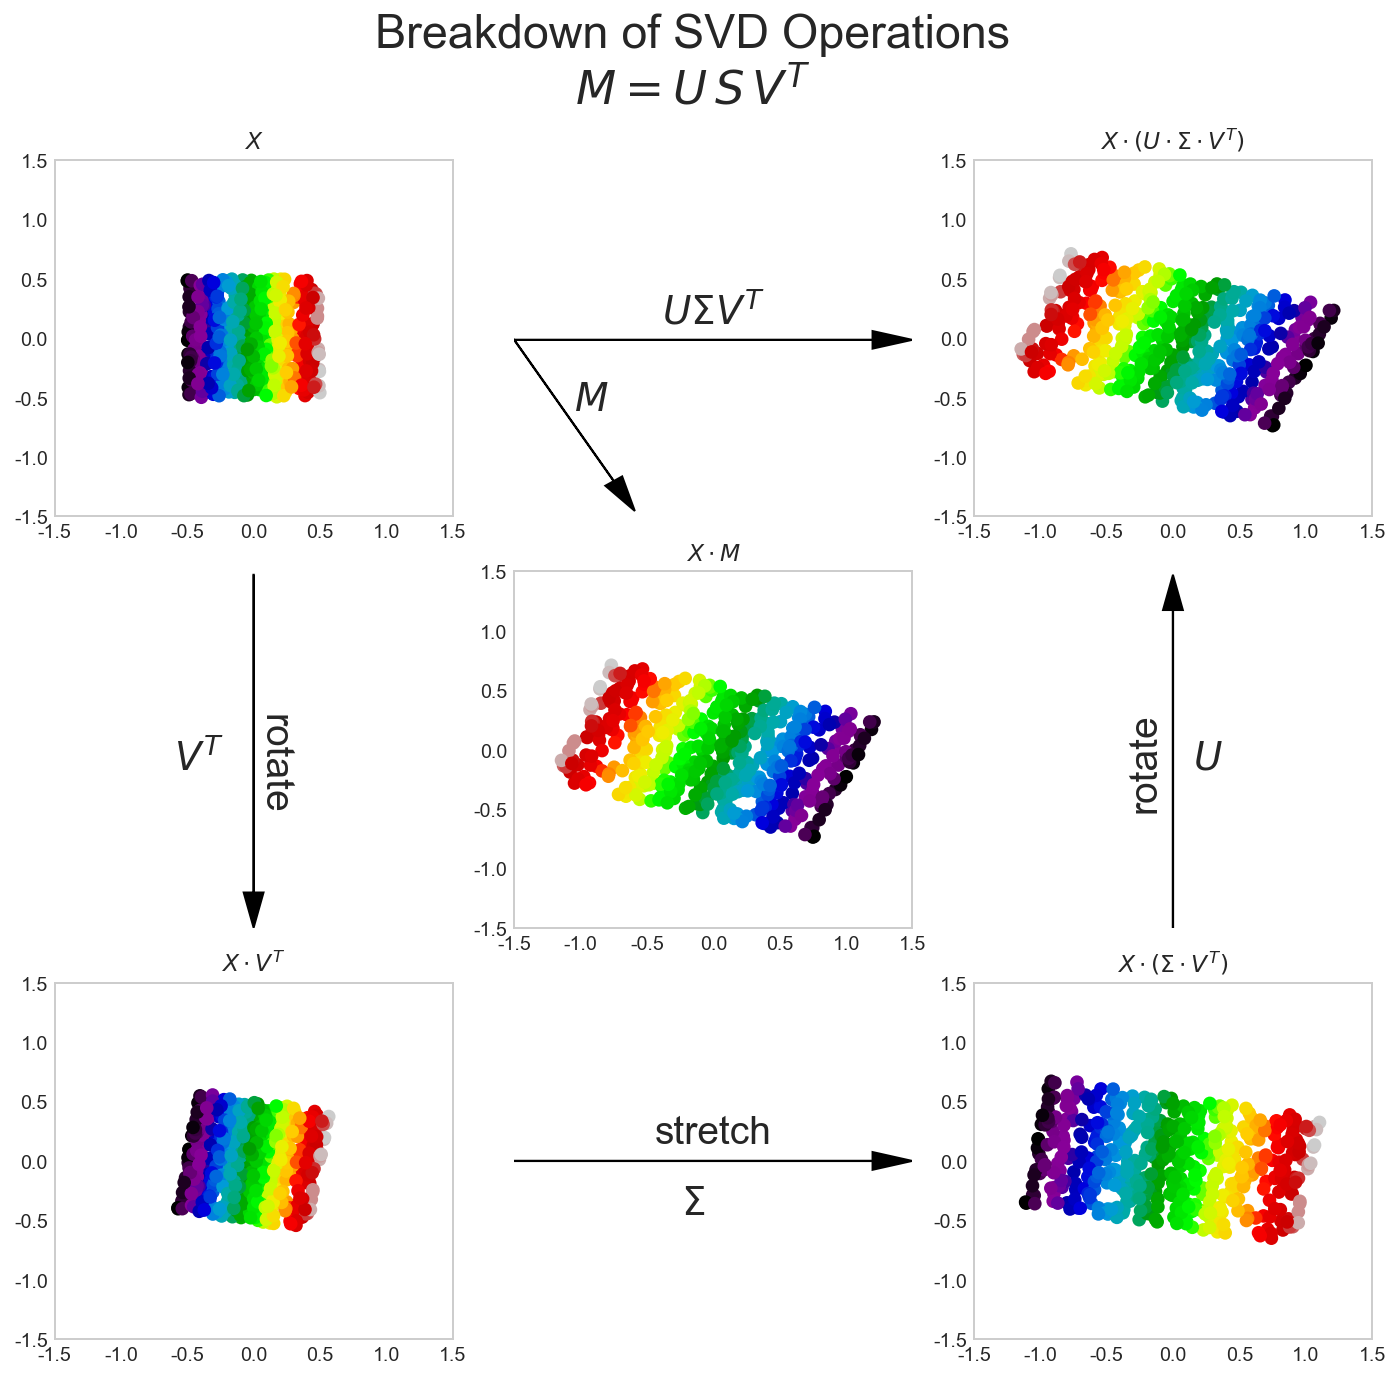

奇异值 = [2.0811 1.0811]
||M - UΣV^T|| = 9.222205069512407e-16
||XM - X(UΣV^T)|| = 5.986951190467391e-15


In [3]:
np.random.seed(123)
n_observations = 500
n_dim = 2
X = np.random.rand(n_observations, n_dim) - 0.5

M = np.array([
    [-2.0,  0.5],
    [-0.5, -1.0],
])

colors = X[:, 0]
cmap = "nipy_spectral"

U, singular_values, Vt = svd(M)
S = np.diag(singular_values)

fig, axs = plt.subplots(3, 3, figsize=(10, 10))
plt.suptitle("Breakdown of SVD Operations\n$M = U\\,S\\,V^T$",
             fontsize=24, ha="center")

plt.sca(axs[0][0])
plt.scatter(X[:, 0], X[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.grid()
plt.title("$X$")

XM = X @ M
plt.sca(axs[1][1])
plt.scatter(XM[:, 0], XM[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.grid()
plt.title("$X \\cdot M$")

XVt = X @ Vt
plt.sca(axs[2][0])
plt.scatter(XVt[:, 0], XVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.grid()
plt.title("$X \\cdot V^T$")

XSVt = X @ (S @ Vt)
plt.sca(axs[2][2])
plt.scatter(XSVt[:, 0], XSVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.grid()
plt.title("$X \\cdot (\\Sigma \\cdot V^T)$")

XUSVt = X @ (U @ S @ Vt)
plt.sca(axs[0][2])
plt.scatter(XUSVt[:, 0], XUSVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.grid()
plt.title("$X \\cdot (U \\cdot \\Sigma \\cdot V^T)$")

plt.sca(axs[0][1])
plt.arrow(0.0, 0.5, 0.9, 0.0, capstyle="round",
          head_width=0.05, head_length=0.1, fc="black")
plt.arrow(0.0, 0.5, 0.25, -0.4, capstyle="round",
          head_width=0.05, head_length=0.1, fc="black")
plt.text(0.15, 0.3, "$M$", fontsize=20)
plt.text(0.5, 0.55, "$U\\Sigma V^T$", fontsize=20, ha="center")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.axis("off")

plt.sca(axs[1][0])
plt.arrow(0.5, 1.0, 0.0, -0.9, capstyle="round",
          head_width=0.05, head_length=0.1, fc="black")
plt.text(0.3, 0.45, "$V^T$", fontsize=20)
plt.text(0.55, 0.35, "rotate", fontsize=20, ha="center", rotation=-90)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.axis("off")

plt.sca(axs[2][1])
plt.arrow(0.0, 0.5, 0.9, 0.0, capstyle="round",
          head_width=0.05, head_length=0.1, fc="black")
plt.text(0.42, 0.35, "$\\Sigma$", fontsize=20)
plt.text(0.5, 0.55, "stretch", fontsize=20, ha="center")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.axis("off")

plt.sca(axs[1][2])
plt.arrow(0.5, 0.0, 0.0, 0.9, capstyle="round",
          head_width=0.05, head_length=0.1, fc="black")
plt.text(0.55, 0.45, "$U$", fontsize=20)
plt.text(0.43, 0.35, "rotate", fontsize=20, ha="center", rotation=90)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.01])
plt.axis("off")

plt.tight_layout()
plt.show()

print("奇异值 =", singular_values)
print("||M - UΣV^T|| =", np.linalg.norm(M - U @ S @ Vt))
print("||XM - X(UΣV^T)|| =", np.linalg.norm(XM - XUSVt))

几何上，

$$
V^\top:\ \text{选取输入空间中的主方向}
$$

$$
\Sigma:\ \text{仅沿标准坐标轴缩放}
$$

$$
U:\ \text{将标准基旋转到输出空间的主方向}
$$


更严格地说，$U$ 与 $V$ 都是正交矩阵（或列正交矩阵），满足

$$
U^\top U = I,
\qquad
V^\top V = I
$$

因此它们保持内积、长度与夹角；真正改变尺度的是 $\Sigma$。这正是奇异值分解能够把“方向变化”和“尺度变化”清晰分离的原因。


## 理解二：low-rank 近似

由

$$
A = \sum_{i=1}^{r}\sigma_i u_i v_i^\top
$$

截断得到

$$
A_k = \sum_{i=1}^{k}\sigma_i u_i v_i^\top
$$

则 $A_k$ 是最优 rank-$k$ 近似（Eckart--Young 定理）：

$$
A_k = \arg\min_{\operatorname{rank}(B)\le k}\|A-B\|_F
$$

把灰度图像看成矩阵后，截断 SVD 就对应图像压缩。


这里的 low-rank 近似不是经验性的，而是严格最优的。除了 Frobenius 范数外，在谱范数下也有

$$
\|A-A_k\|_2 = \sigma_{k+1},
\qquad
\|A-A_k\|_F^2 = \sum_{i>k}\sigma_i^2
$$

因此奇异值衰减越快，截断后的近似越有效；这也是后续张量截断能够成立的数学基础。


## 两种理解的交融

前面的两种理解并不矛盾，而是彼此对应：

$$
A = U\Sigma V^\top
$$

从几何上看，$U$ 与 $V$ 决定主方向，$\Sigma$ 决定各主方向上的缩放强度；从近似角度看，奇异值的大小刻画了各个秩一分量的重要性。

因此，在工程与数值计算中，SVD 常按保留信息的方式区分为：

- 完全型 SVD
- 经济型 SVD
- 紧凑型 SVD
- 截断型 SVD

下面的示意图强调的是这种“结构分解”视角。


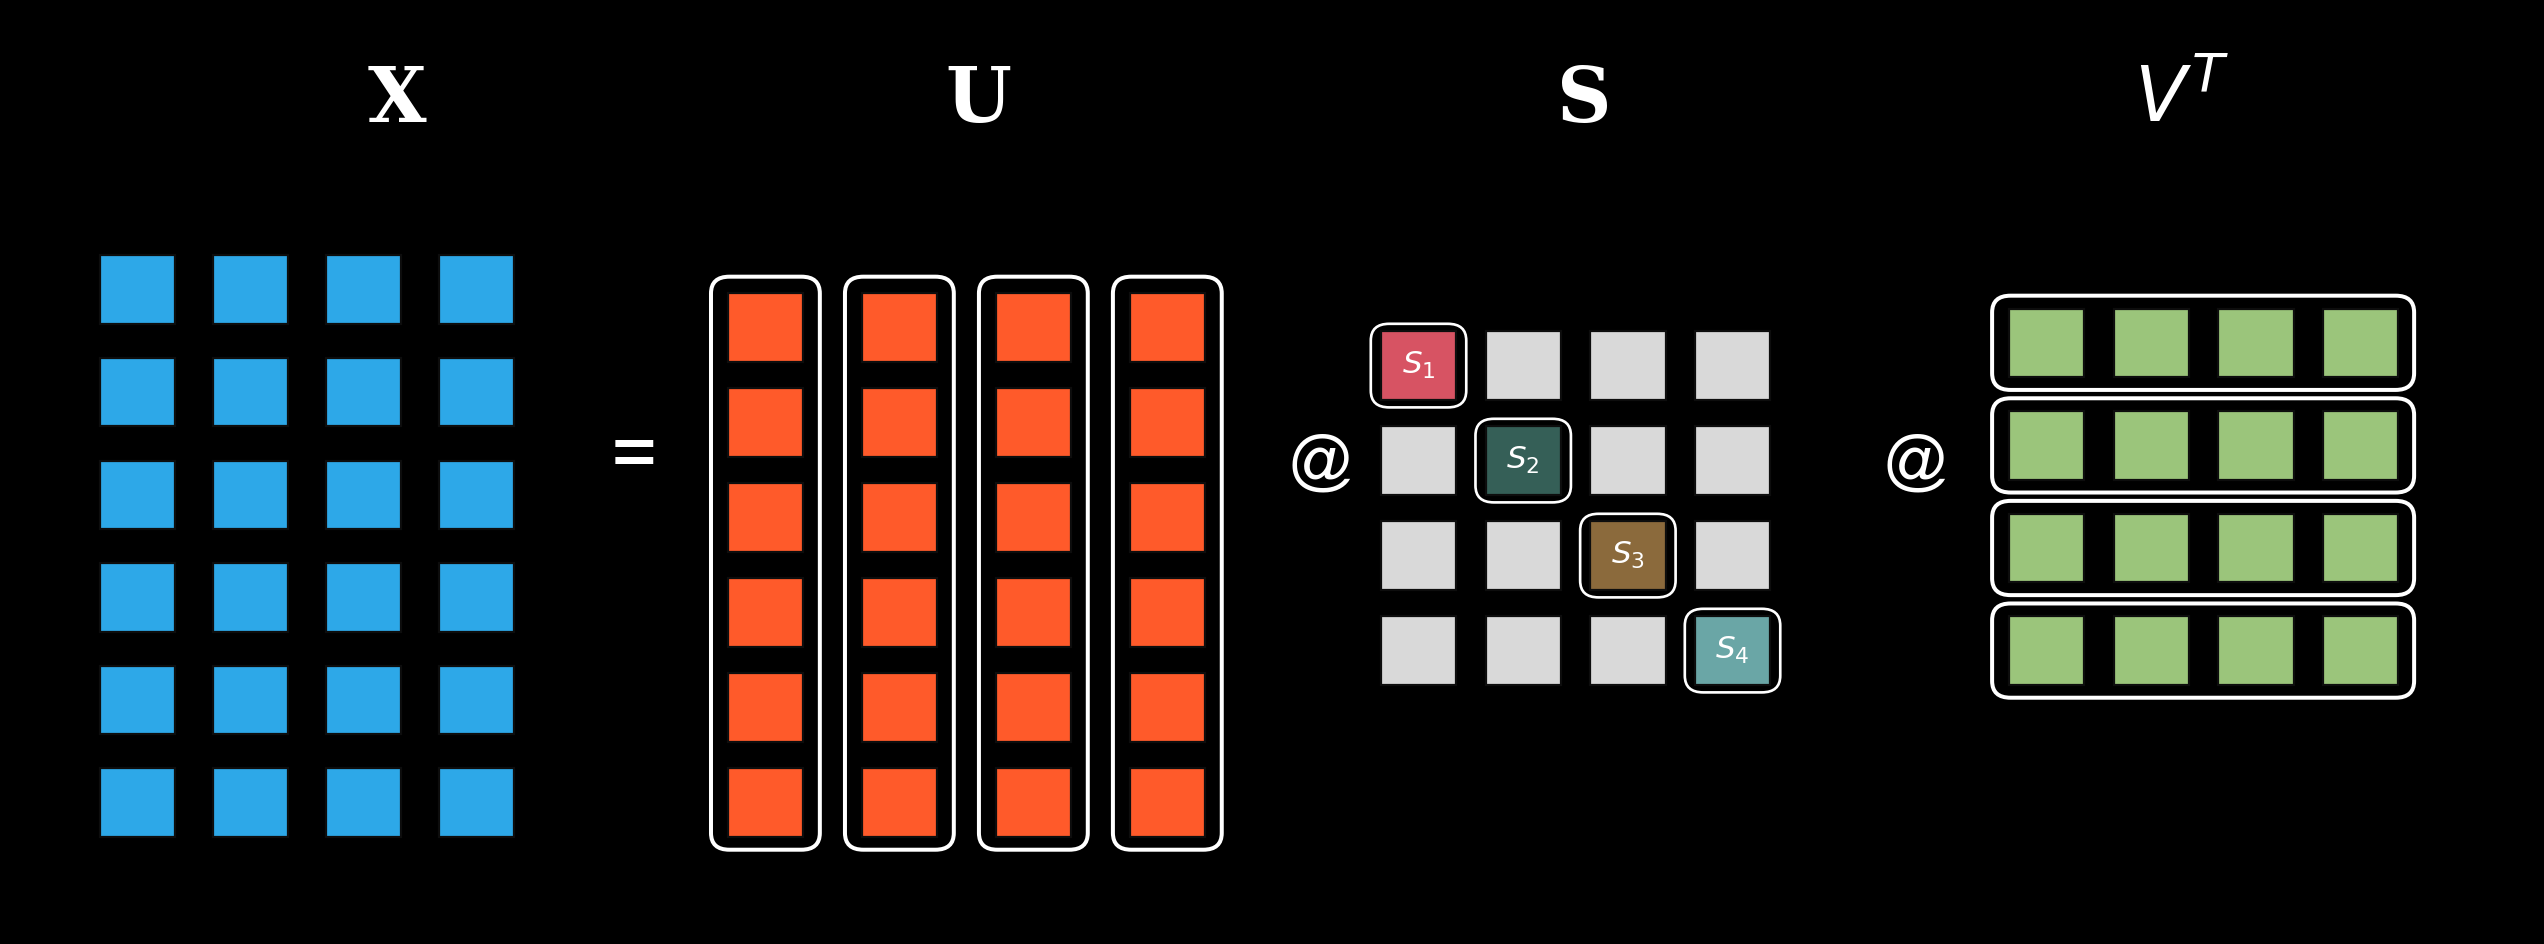

In [4]:
# ========= 基础绘图函数 =========
def add_square(ax, x, y, s=0.9, fc="#35A7E8", ec="#0d0d0d", lw=1.0, text=None,
               text_color="white", fontsize=16):
    ax.add_patch(Rectangle((x, y), s, s, facecolor=fc,
                 edgecolor=ec, linewidth=lw))
    if text is not None:
        ax.text(
            x + s / 2,
            y + s / 2,
            text,
            color=text_color,
            ha="center",
            va="center",
            fontsize=fontsize,
            fontweight="bold",
        )


def add_round_box(ax, x, y, w, h, ec="white", lw=2.0, rounding=0.25):
    ax.add_patch(
        FancyBboxPatch(
            (x, y), w, h,
            boxstyle=f"round,pad=0.02,rounding_size={rounding}",
            linewidth=lw, edgecolor=ec, facecolor="none"
        )
    )


def draw_grid(ax, x0, y0, rows, cols, s=0.9, gap=0.35, color="#35A7E8"):
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (s + gap)
            y = y0 + (rows - 1 - i) * (s + gap)
            add_square(ax, x, y, s=s, fc=color)


# ========= 画图 =========
fig, ax = plt.subplots(figsize=(16, 6), dpi=160)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")
ax.set_xlim(0, 30)
ax.set_ylim(0, 12)
ax.axis("off")

# 标题字母
ax.text(4.2, 10.6, "X", color="white", fontsize=34,
        fontweight="bold", family="serif")
ax.text(11.1, 10.6, "U", color="white", fontsize=34,
        fontweight="bold", family="serif")
ax.text(18.4, 10.6, "S", color="white", fontsize=34,
        fontweight="bold", family="serif")
ax.text(25.3, 10.6, r"$V^T$", color="white",
        fontsize=34, fontweight="bold", family="serif")

# 左侧 X：6x4 矩阵块
draw_grid(ax, x0=1.0, y0=1.2, rows=6, cols=4, s=0.9, gap=0.45, color="#2DA8E8")

# 等号
ax.text(7.1, 5.9, "=", color="white", fontsize=36, fontweight="bold")

# U：6x4 红色方块，每列加白色圆角框
u_x0, u_y0 = 8.5, 1.2
rows_u, cols_u = 6, 4
s, gap = 0.9, 0.35

for j in range(cols_u):
    x_col = u_x0 + j * (s + gap + 0.35)
    total_h = rows_u * s + (rows_u - 1) * gap + 0.35
    add_round_box(ax, x_col - 0.18, u_y0 - 0.15, s + 0.36,
                  total_h, ec="white", lw=1.8, rounding=0.22)
    for i in range(rows_u):
        y = u_y0 + (rows_u - 1 - i) * (s + gap)
        add_square(ax, x_col, y, s=s, fc="#FF5A2A", ec="#0d0d0d", lw=1.0)

# @ 符号 1
ax.text(15.2, 5.9, "@", color="white", fontsize=28, fontweight="bold")

# Sigma：4x4 对角矩阵
s_x0, s_y0 = 16.3, 3.2
rows_s, cols_s = 4, 4
diag_colors = ["#D75363", "#355F57", "#8B6A3C", "#6AA6A6"]

for i in range(rows_s):
    for j in range(cols_s):
        x = s_x0 + j * (s + 0.35)
        y = s_y0 + (rows_s - 1 - i) * (s + 0.35)
        if i == j:
            add_square(ax, x, y, s=s, fc=diag_colors[i], ec="#0d0d0d", lw=1.0,
                       text=fr"$S_{i+1}$", fontsize=14)
            add_round_box(ax, x - 0.10, y - 0.08, s + 0.20, s + 0.16,
                          ec="white", lw=1.2, rounding=0.22)
        else:
            add_square(ax, x, y, s=s, fc="#D9D9D9", ec="#0d0d0d", lw=1.0)

# @ 符号 2
ax.text(22.3, 5.9, "@", color="white", fontsize=28, fontweight="bold")

# V^T：4x4 绿色方块，每行加白色圆角框
vt_x0, vt_y0 = 23.8, 3.2
rows_v, cols_v = 4, 4

for i in range(rows_v):
    y_row = vt_y0 + (rows_v - 1 - i) * (s + 0.45)
    total_w = cols_v * s + (cols_v - 1) * 0.35 + 0.35
    add_round_box(ax, vt_x0 - 0.18, y_row - 0.15, total_w, s + 0.30,
                  ec="white", lw=1.8, rounding=0.22)
    for j in range(cols_v):
        x = vt_x0 + j * (s + 0.35)
        add_square(ax, x, y_row, s=s, fc="#9BC57B", ec="#0d0d0d", lw=1.0)

plt.tight_layout()
plt.show()

# 如需保存：
# plt.savefig("svd_diagram.png", dpi=300, facecolor="black", bbox_inches="tight")

## 经济型 SVD

设矩阵 $X\in\mathbb{R}^{n\times D}$，且 $D\le n$。完全型 SVD 可写为

$$
X = U\Sigma V^\top,
\qquad
U\in\mathbb{R}^{n\times n},
\quad
\Sigma\in\mathbb{R}^{n\times D},
\quad
V\in\mathbb{R}^{D\times D}
$$

其中 $\Sigma$ 可以看成上方为 $D\times D$ 对角块、下方为全零块的矩阵。相应地，$U$ 可按列分块为

$$
U = [U_1\ U_2],
\qquad
U_1\in\mathbb{R}^{n\times D},
\quad
U_2\in\mathbb{R}^{n\times (n-D)}
$$

去掉 $\Sigma$ 中的零块以及 $U_2$ 后，得到经济型 SVD：

$$
X = U_1\Sigma_1 V^\top
$$

这说明经济型 SVD 只保留与非零奇异值对应的子空间，因此在数值实现中更紧凑。


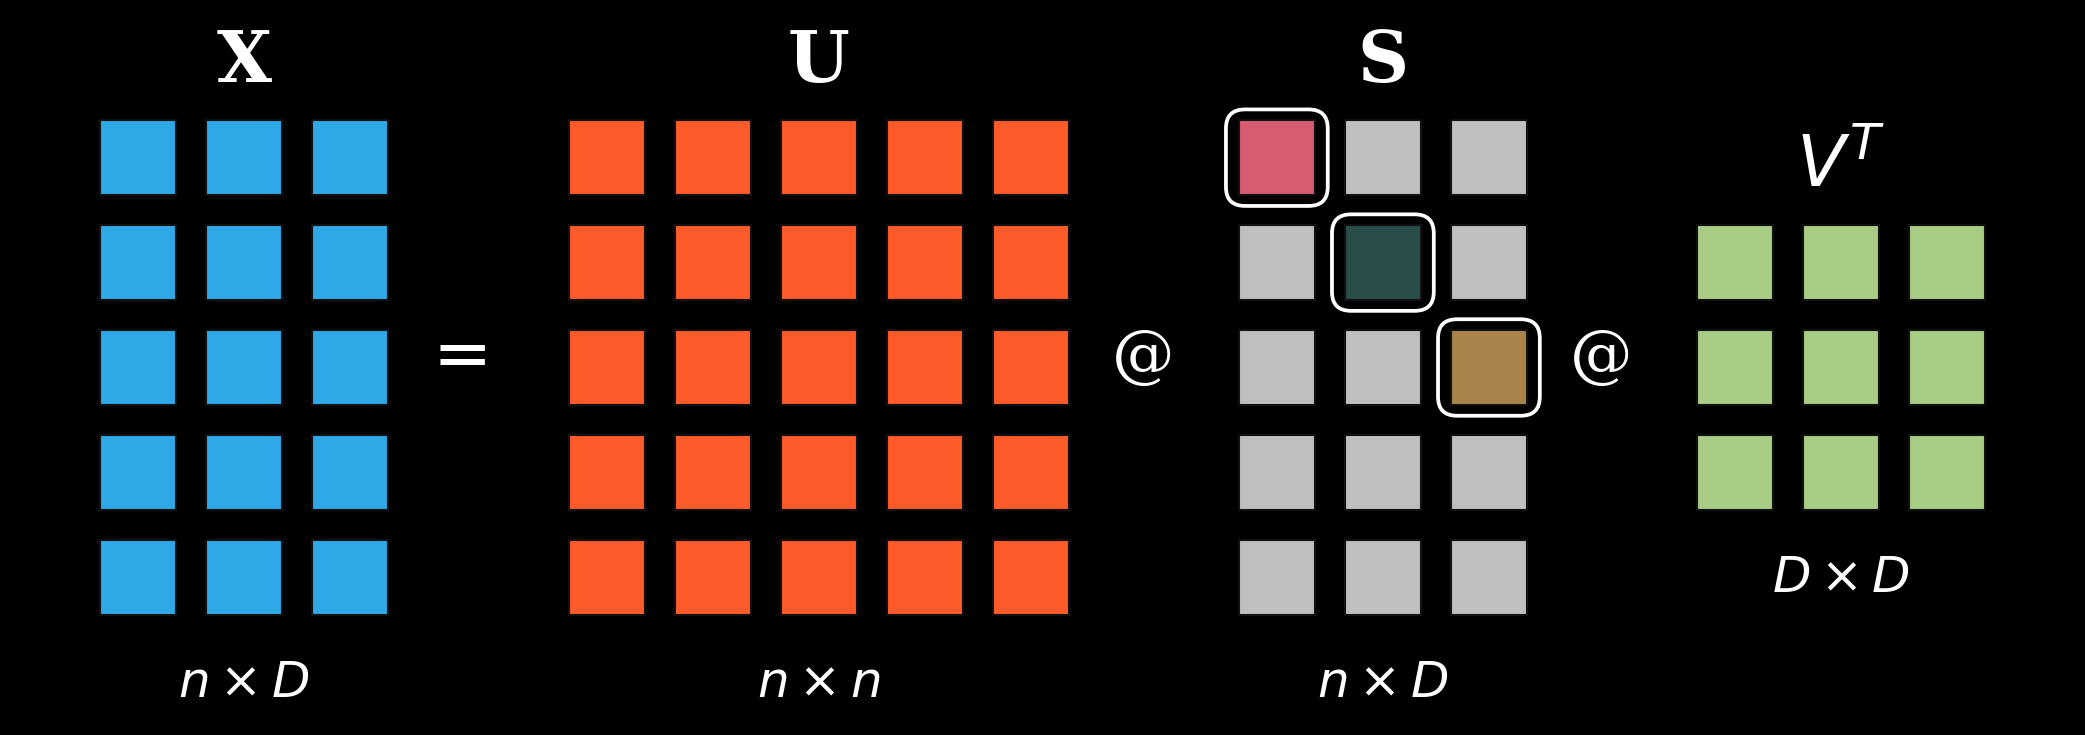

In [5]:
# =========================
# 可调参数
# =========================
n = 5   # 行数
D = 3   # 列数

bg_color = "black"
blue = "#2EA8E6"
orange = "#FF5A2A"
green = "#A9CC84"
gray = "#BFBFBF"

diag_colors = ["#D85C71", "#294D48", "#A8844B"]

sq = 0.72          # 小方块边长
gap = 0.28         # 小方块间距
group_gap = 1.5    # 各矩阵之间的间距

title_fs = 34
label_fs = 24
symbol_fs = 34

# =========================
# 基础函数
# =========================


def draw_block_matrix(ax, x0, y0, rows, cols, color, edgecolor="#111111",
                      size=0.72, gap=0.28):
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (size + gap)
            y = y0 + (rows - 1 - i) * (size + gap)
            ax.add_patch(Rectangle(
                (x, y), size, size,
                facecolor=color, edgecolor=edgecolor, linewidth=1.0
            ))


def draw_sigma_matrix(ax, x0, y0, rows, cols, base_color, diag_colors,
                      size=0.72, gap=0.28):
    diag_len = min(rows, cols, len(diag_colors))
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (size + gap)
            y = y0 + (rows - 1 - i) * (size + gap)

            color = base_color
            if i == j and i < diag_len:
                color = diag_colors[i]

            ax.add_patch(Rectangle(
                (x, y), size, size,
                facecolor=color, edgecolor="#111111", linewidth=1.0
            ))

            if i == j and i < diag_len:
                ax.add_patch(FancyBboxPatch(
                    (x - 0.10, y - 0.08),
                    size + 0.20, size + 0.16,
                    boxstyle="round,pad=0.02,rounding_size=0.18",
                    linewidth=1.8, edgecolor="white", facecolor="none"
                ))


def matrix_width(cols, size=0.72, gap=0.28):
    return cols * size + (cols - 1) * gap


def matrix_height(rows, size=0.72, gap=0.28):
    return rows * size + (rows - 1) * gap


# =========================
# 画图
# =========================
fig, ax = plt.subplots(figsize=(14, 5), dpi=150)
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)
ax.axis("off")

# 统一底部 y
y0 = 1.0

# 各块宽高
wX = matrix_width(D, sq, gap)
hX = matrix_height(n, sq, gap)

wU = matrix_width(n, sq, gap)
hU = matrix_height(n, sq, gap)

wS = matrix_width(D, sq, gap)
hS = matrix_height(n, sq, gap)

wV = matrix_width(D, sq, gap)
hV = matrix_height(D, sq, gap)

# 横向布局
xX = 0.8
xEq = xX + wX + 0.7
xU = xEq + 1.0
xAt1 = xU + wU + 0.7
xS = xAt1 + 0.9
xAt2 = xS + wS + 0.7
xV = xAt2 + 0.9

# 画 X
draw_block_matrix(ax, xX, y0, n, D, blue, size=sq, gap=gap)
ax.text(xX + wX/2, y0 + hX + 0.55, "X",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xX + wX/2, y0 - 0.65, r"$n \times D$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# 等号
ax.text(xEq, y0 + hX*0.52, "=",
        color="white", ha="center", va="center",
        fontsize=symbol_fs, family="serif")

# 画 U
draw_block_matrix(ax, xU, y0, n, n, orange, size=sq, gap=gap)
ax.text(xU + wU/2, y0 + hU + 0.55, "U",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xU + wU/2, y0 - 0.65, r"$n \times n$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# @
ax.text(xAt1, y0 + hX*0.52, "@",
        color="white", ha="center", va="center",
        fontsize=symbol_fs - 4, family="serif")

# 画 S
draw_sigma_matrix(ax, xS, y0, n, D, gray, diag_colors, size=sq, gap=gap)
ax.text(xS + wS/2, y0 + hS + 0.55, "S",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xS + wS/2, y0 - 0.65, r"$n \times D$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# @
ax.text(xAt2, y0 + hX*0.52, "@",
        color="white", ha="center", va="center",
        fontsize=symbol_fs - 4, family="serif")

# 画 V^T
draw_block_matrix(ax, xV, y0 + (hX - hV) / 2, D, D, green, size=sq, gap=gap)
ax.text(xV + wV/2, y0 + (hX - hV) / 2 + hV + 0.55, r"$V^T$",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xV + wV/2, y0 + (hX - hV) / 2 - 0.65, r"$D \times D$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# 设置显示范围
xmax = xV + wV + 0.8
ymax = y0 + hX + 1.0
ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)

plt.tight_layout()
plt.show()

# 保存图片可取消注释
# plt.savefig("svd_style_diagram.png", dpi=300, facecolor=bg_color, bbox_inches="tight")

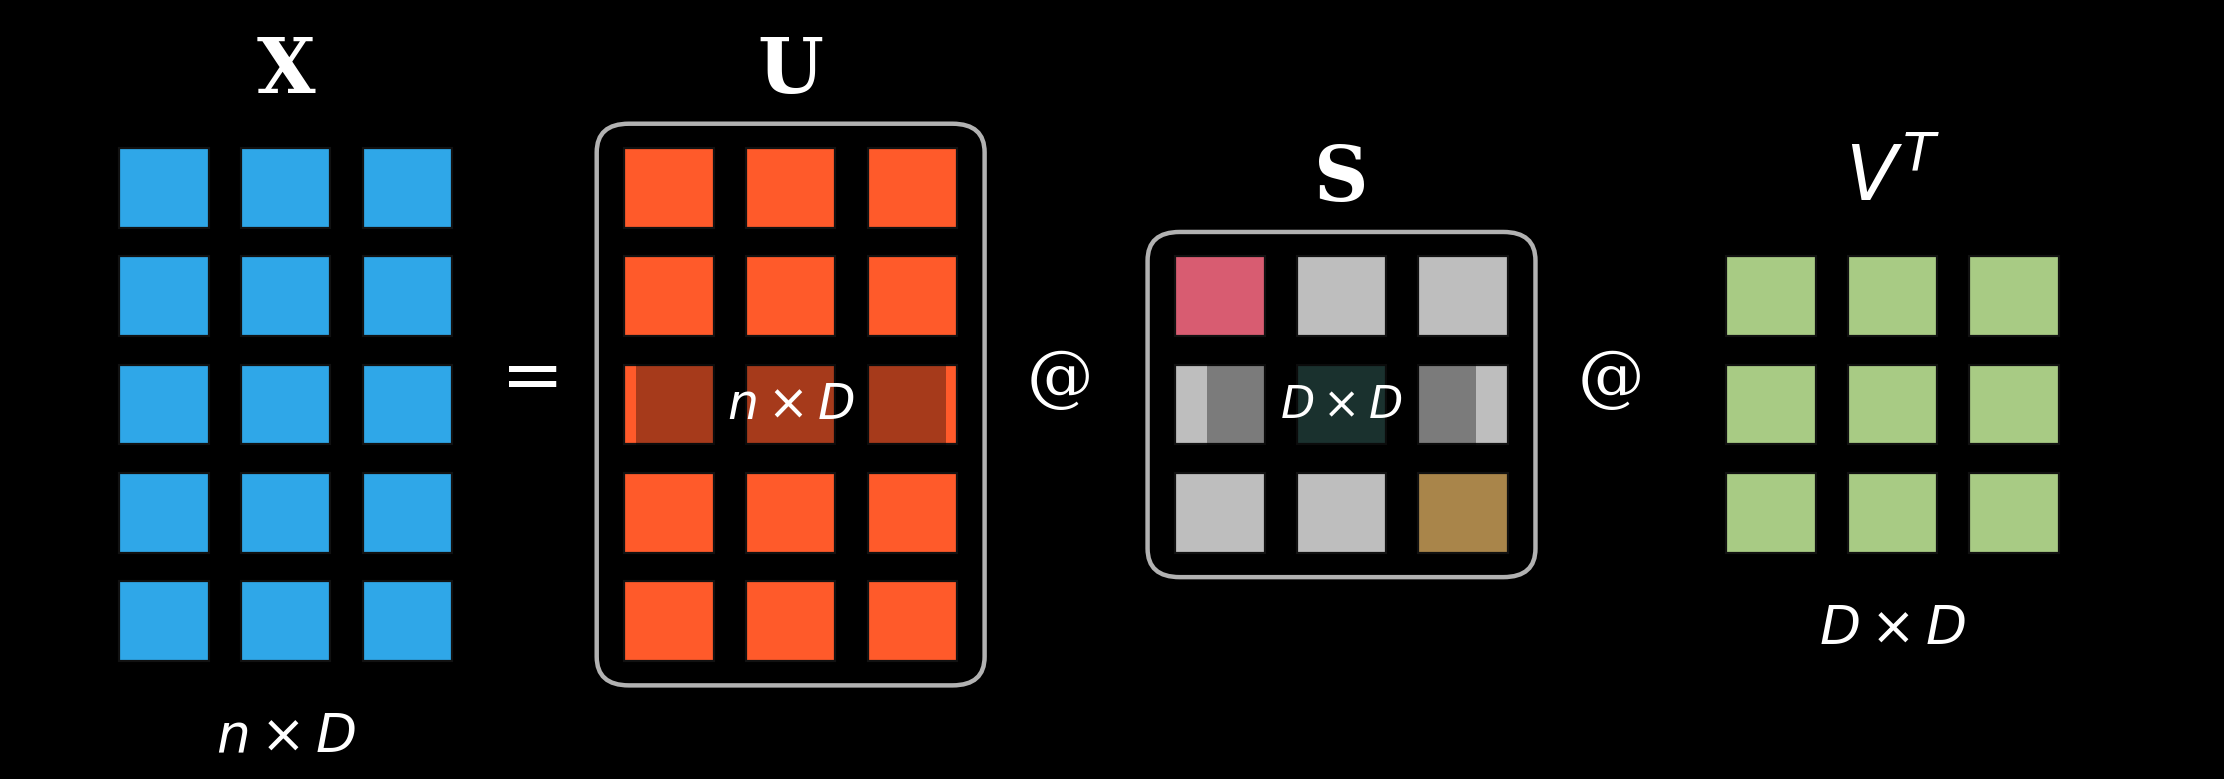

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

# =========================
# 参数
# =========================
n = 5
D = 3

sq = 0.78          # 方块边长
gap = 0.28         # 方块间距
bg = "black"

cX = "#2FA7E8"
cU = "#FF5A2A"
cV = "#A8CB84"
cG = "#BEBEBE"
diag_colors = ["#D85C71", "#284C47", "#A9854A"]

# =========================
# 工具函数
# =========================


def mat_w(cols, sq=sq, gap=gap):
    return cols * sq + (cols - 1) * gap


def mat_h(rows, sq=sq, gap=gap):
    return rows * sq + (rows - 1) * gap


def draw_grid(ax, x0, y0, rows, cols, color, sq=sq, gap=gap, edge="#111111"):
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (sq + gap)
            y = y0 + (rows - 1 - i) * (sq + gap)
            ax.add_patch(Rectangle((x, y), sq, sq, facecolor=color,
                                   edgecolor=edge, linewidth=1.0))


def draw_sigma(ax, x0, y0, rows, cols, base_color, diag_colors, sq=sq, gap=gap, edge="#111111"):
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (sq + gap)
            y = y0 + (rows - 1 - i) * (sq + gap)
            color = base_color
            if i == j and i < len(diag_colors):
                color = diag_colors[i]
            ax.add_patch(Rectangle((x, y), sq, sq, facecolor=color,
                                   edgecolor=edge, linewidth=1.0))


def draw_round_box(ax, x, y, w, h, lw=2.0):
    ax.add_patch(FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.28",
        linewidth=lw, edgecolor="white", facecolor="none", alpha=0.7
    ))


def draw_center_label(ax, xc, yc, text, box_w, box_h,
                      face=(0, 0, 0, 0.35), fs=24):
    ax.add_patch(Rectangle(
        (xc - box_w/2, yc - box_h/2), box_w, box_h,
        facecolor=face, edgecolor="none"
    ))
    ax.text(xc, yc, text, color="white", ha="center", va="center",
            fontsize=fs, family="serif")


# =========================
# 画图
# =========================
fig, ax = plt.subplots(figsize=(14, 5), dpi=160)
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)
ax.axis("off")

# 统一基线
y0 = 1.0

# 各矩阵尺寸
wX, hX = mat_w(D), mat_h(n)
wU, hU = mat_w(D), mat_h(n)   # 按图中效果，U画成 n×D 的块阵
wS, hS = mat_w(D), mat_h(D)   # S画成 D×D
wV, hV = mat_w(D), mat_h(D)   # V^T 画成 D×D

# 横向布局
xX = 0.9
xEq = xX + wX + 0.7
xU = xEq + 0.8
xAt1 = xU + wU + 0.9
xS = xAt1 + 1.0
xAt2 = xS + wS + 0.9
xV = xAt2 + 1.0

# 让 S 和 V 在竖直方向居中对齐到 X/U 的中部
yS = y0 + (hX - hS) / 2
yV = y0 + (hX - hV) / 2

# X
draw_grid(ax, xX, y0, n, D, cX)
ax.text(xX + wX/2, y0 + hX + 0.75, "X",
        color="white", ha="center", va="center",
        fontsize=34, family="serif", fontweight="bold")
ax.text(xX + wX/2, y0 - 0.75, r"$n \times D$",
        color="white", ha="center", va="center",
        fontsize=24, family="serif")

# =
ax.text(xEq, y0 + hX*0.55, "=",
        color="white", ha="center", va="center",
        fontsize=34, family="serif")

# U
draw_grid(ax, xU, y0, n, D, cU)
draw_round_box(ax, xU - 0.22, y0 - 0.22, wU + 0.44, hU + 0.44, lw=2.0)
ax.text(xU + wU/2, y0 + hU + 0.75, "U",
        color="white", ha="center", va="center",
        fontsize=34, family="serif", fontweight="bold")
draw_center_label(ax, xU + wU/2, y0 + hU/2, r"$n \times D$",
                  box_w=2.7, box_h=0.95, fs=22)

# @
ax.text(xAt1, y0 + hX*0.55, "@",
        color="white", ha="center", va="center",
        fontsize=30, family="serif")

# S
draw_sigma(ax, xS, yS, D, D, cG, diag_colors)
draw_round_box(ax, xS - 0.22, yS - 0.22, wS + 0.44, hS + 0.44, lw=2.0)
ax.text(xS + wS/2, yS + hS + 0.75, "S",
        color="white", ha="center", va="center",
        fontsize=34, family="serif", fontweight="bold")
draw_center_label(ax, xS + wS/2, yS + hS/2, r"$D \times D$",
                  box_w=2.35, box_h=0.9, fs=20)

# @
ax.text(xAt2, y0 + hX*0.55, "@",
        color="white", ha="center", va="center",
        fontsize=30, family="serif")

# V^T
draw_grid(ax, xV, yV, D, D, cV)
ax.text(xV + wV/2, yV + hV + 0.75, r"$V^T$",
        color="white", ha="center", va="center",
        fontsize=34, family="serif", fontweight="bold")
ax.text(xV + wV/2, yV - 0.75, r"$D \times D$",
        color="white", ha="center", va="center",
        fontsize=24, family="serif")

# 范围
ax.set_xlim(0, xV + wV + 1.3)
ax.set_ylim(0, y0 + hX + 1.3)

plt.tight_layout()
plt.show()

# 保存：
# plt.savefig("svd_block_style.png", dpi=300, facecolor=bg, bbox_inches="tight")

## 紧凑型SVD分解

在经济型SVD分解的基础上，可以获得紧凑型SVD分解；
假如原始矩阵是非满秩的，即rank(x) = r < D;
此时对x进行SVD，得到的矩阵S中，只有r个非零对角元素，因此可以进一步将奇异值矩阵S缩减为r*r对角方阵；
同时将左奇异值矩阵U缩减为n*r的矩阵；
将右奇异值矩阵V缩减为r\*D的矩阵；
只有在原始矩阵x非满秩的情况下，经济型SVD才存在对应的紧凑型SVD;


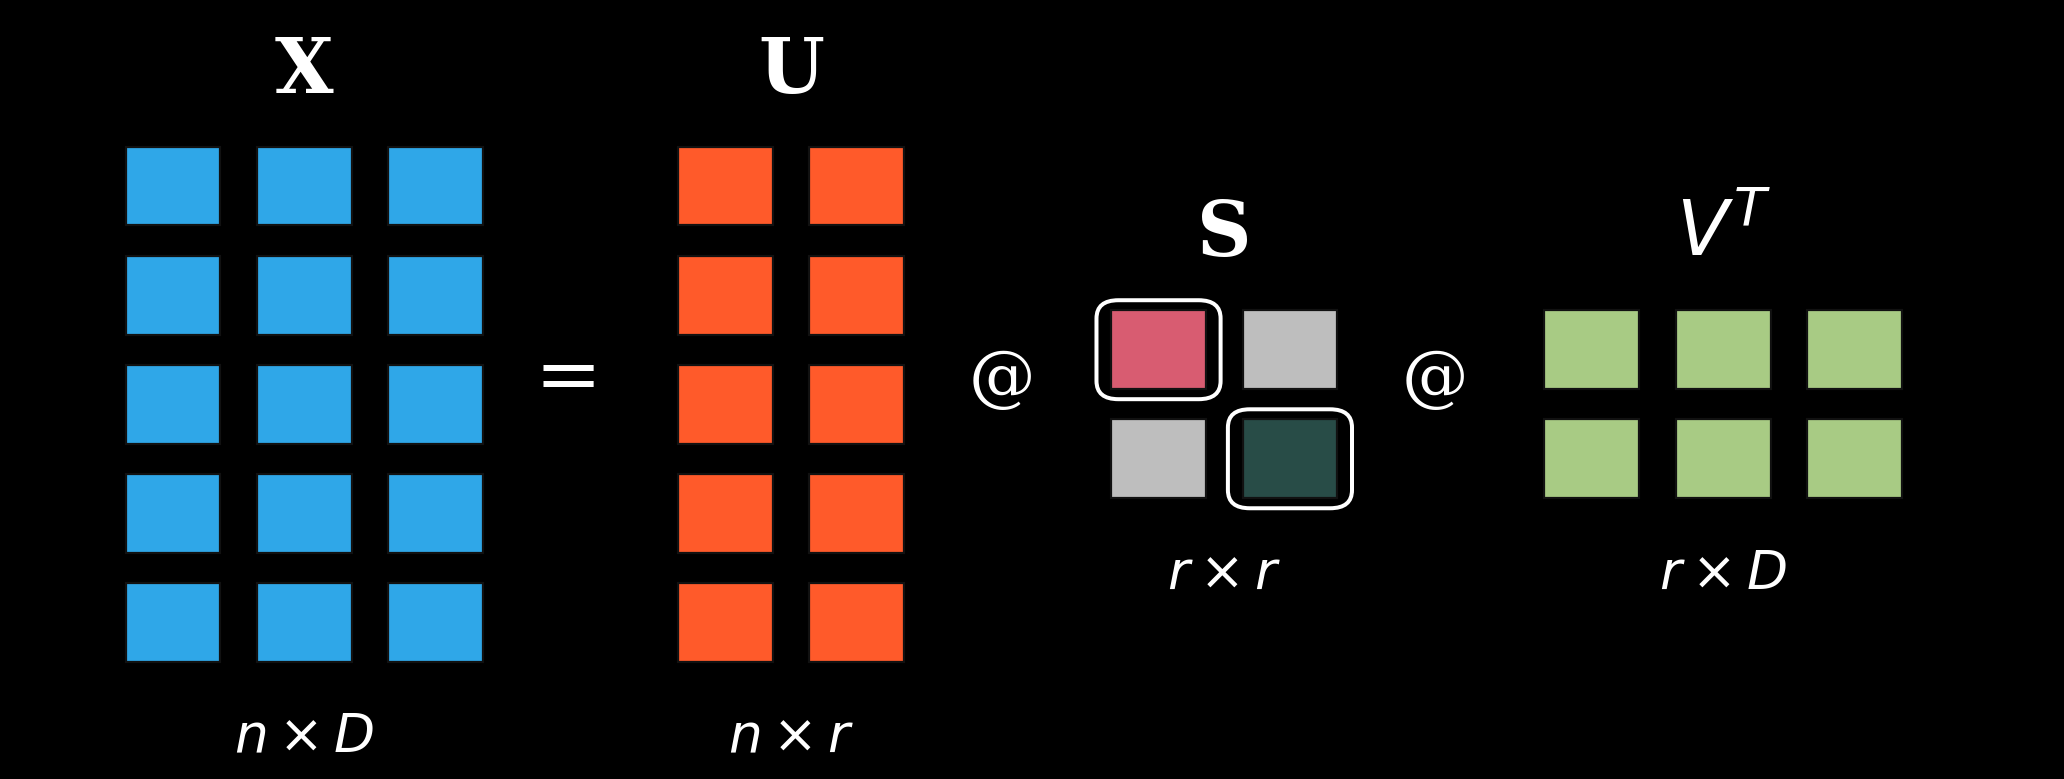

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

# =========================
# 参数
# =========================
n = 5   # X 和 U 的行数
D = 3   # X 的列数 / V^T 的列数
r = 2   # 截断秩

sq = 0.78
gap = 0.30
bg = "black"

cX = "#2FA7E8"
cU = "#FF5A2A"
cV = "#A8CB84"
cG = "#BEBEBE"
diag_colors = ["#D85C71", "#284C47"]

title_fs = 34
label_fs = 24
symbol_fs = 30

# =========================
# 工具函数
# =========================


def mat_w(cols, sq=sq, gap=gap):
    return cols * sq + (cols - 1) * gap


def mat_h(rows, sq=sq, gap=gap):
    return rows * sq + (rows - 1) * gap


def draw_grid(ax, x0, y0, rows, cols, color, sq=sq, gap=gap, edge="#111111"):
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (sq + gap)
            y = y0 + (rows - 1 - i) * (sq + gap)
            ax.add_patch(Rectangle(
                (x, y), sq, sq,
                facecolor=color, edgecolor=edge, linewidth=1.0
            ))


def draw_sigma(ax, x0, y0, rows, cols, base_color, diag_colors, sq=sq, gap=gap):
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (sq + gap)
            y = y0 + (rows - 1 - i) * (sq + gap)

            color = base_color
            if i == j and i < len(diag_colors):
                color = diag_colors[i]

            ax.add_patch(Rectangle(
                (x, y), sq, sq,
                facecolor=color, edgecolor="#111111", linewidth=1.0
            ))

            if i == j and i < len(diag_colors):
                ax.add_patch(FancyBboxPatch(
                    (x - 0.10, y - 0.08),
                    sq + 0.20, sq + 0.16,
                    boxstyle="round,pad=0.02,rounding_size=0.18",
                    linewidth=1.8, edgecolor="white", facecolor="none"
                ))


# =========================
# 画图
# =========================
fig, ax = plt.subplots(figsize=(13, 5), dpi=160)
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)
ax.axis("off")

y0 = 1.0

# 各块尺寸
wX, hX = mat_w(D), mat_h(n)
wU, hU = mat_w(r), mat_h(n)
wS, hS = mat_w(r), mat_h(r)
wV, hV = mat_w(D), mat_h(r)

# 横向位置
xX = 0.9
xEq = xX + wX + 0.7
xU = xEq + 0.9
xAt1 = xU + wU + 0.8
xS = xAt1 + 0.9
xAt2 = xS + wS + 0.8
xV = xAt2 + 0.9

# 让 S 和 V^T 竖直居中
yS = y0 + (hX - hS) / 2
yV = y0 + (hX - hV) / 2

# X : n x D
draw_grid(ax, xX, y0, n, D, cX)
ax.text(xX + wX/2, y0 + hX + 0.75, "X",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xX + wX/2, y0 - 0.75, r"$n \times D$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# =
ax.text(xEq, y0 + hX*0.55, "=",
        color="white", ha="center", va="center",
        fontsize=36, family="serif")

# U : n x r
draw_grid(ax, xU, y0, n, r, cU)
ax.text(xU + wU/2, y0 + hU + 0.75, "U",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xU + wU/2, y0 - 0.75, r"$n \times r$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# @
ax.text(xAt1, y0 + hX*0.55, "@",
        color="white", ha="center", va="center",
        fontsize=symbol_fs, family="serif")

# S : r x r
draw_sigma(ax, xS, yS, r, r, cG, diag_colors)
ax.text(xS + wS/2, yS + hS + 0.75, "S",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xS + wS/2, yS - 0.75, r"$r \times r$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# @
ax.text(xAt2, y0 + hX*0.55, "@",
        color="white", ha="center", va="center",
        fontsize=symbol_fs, family="serif")

# V^T : r x D
draw_grid(ax, xV, yV, r, D, cV)
ax.text(xV + wV/2, yV + hV + 0.75, r"$V^T$",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")
ax.text(xV + wV/2, yV - 0.75, r"$r \times D$",
        color="white", ha="center", va="center",
        fontsize=label_fs, family="serif")

# 显示范围
ax.set_xlim(0, xV + wV + 1.2)
ax.set_ylim(0, y0 + hX + 1.3)

plt.tight_layout()
plt.show()

# 保存图片可用：
# plt.savefig("truncated_svd_diagram.png", dpi=300, facecolor=bg, bbox_inches="tight")

## 截断型SVD

假设原始矩阵X的秩为r,rank(x) = r < or = D;
在它的经济型奇异值分解中，S的主对角元素，是矩阵X的r个奇异值，且奇异值在对角线上从大到小排列，S1 >= S2 >= S3……;
保留r个奇异值中前P个奇异值，对U，V进行缩减，等效于紧凑型SVD；
由于对非零向量进行了缩减，所以截断型SVD无法还原原始矩阵的所有信息，是原始矩阵X的近似结果；


## SVD分解的本质探讨

假定对一个5x4的原始矩阵x进行SVD分解，通过矩阵乘法的第二视角进行展开，等价于以4个奇异值为倍数，将四个数据矩阵层层叠加；
好比对原始数据进行切片，奇异值越大对应切片的厚度越厚，代表对最终数据的影响越大；奇异值越小则切片越薄，代表对最终数据的影响越小；
基于这种思想，如果前三大奇异值的总和占所有奇异值数值总和的95%以上，那么只需要保留前三个奇异值以及对应的奇异向量矩阵，就能还原出原始数据矩阵95%的信息；
实践中，对精度和效率的衡量往往也是一门有意思的工程问题；


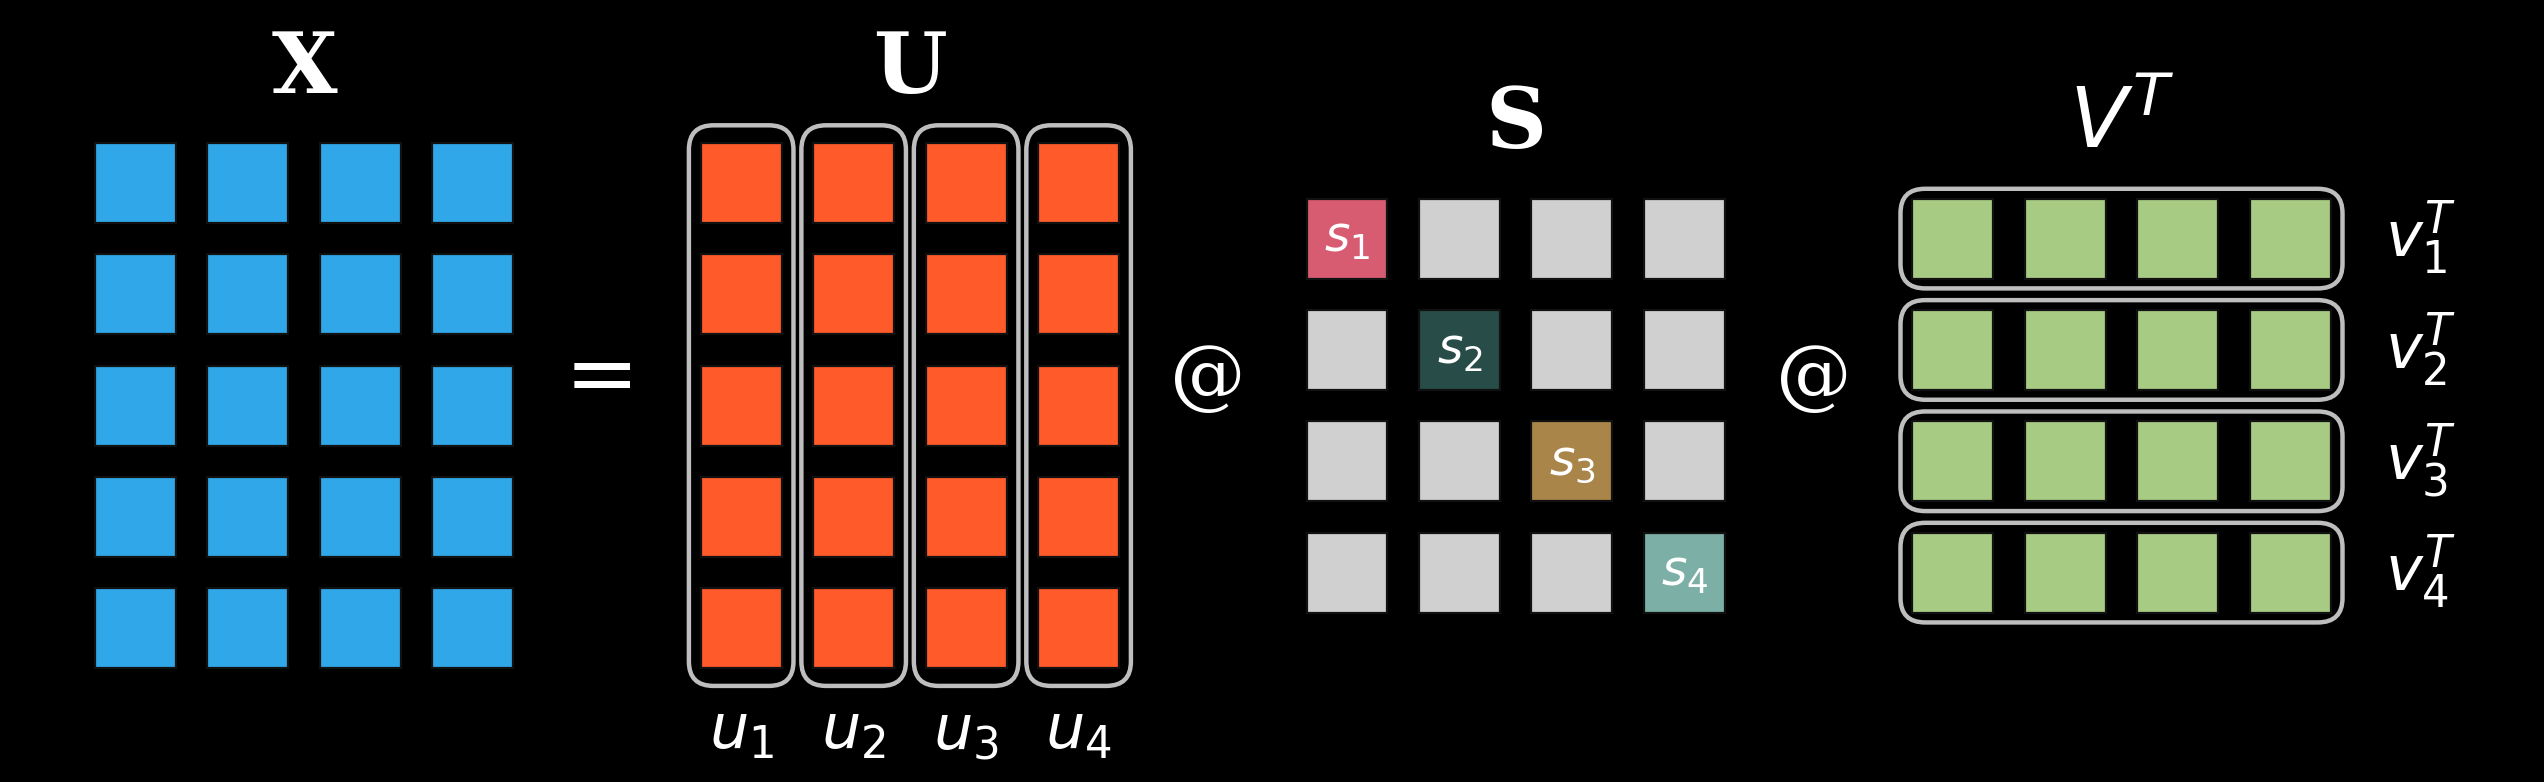

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

# =========================
# 参数
# =========================
rows_X = 5
cols_X = 4

sq = 0.82
gap = 0.32
bg = "black"

cX = "#2FA7E8"
cU = "#FF5A2A"
cV = "#A8CB84"
cG = "#D0D0D0"
diag_colors = ["#D85C71", "#284C47", "#A9854A", "#7CAFA5"]

title_fs = 38
symbol_fs = 34
vec_fs = 28

# =========================
# 基础函数
# =========================


def mat_w(cols, sq=sq, gap=gap):
    return cols * sq + (cols - 1) * gap


def mat_h(rows, sq=sq, gap=gap):
    return rows * sq + (rows - 1) * gap


def draw_grid(ax, x0, y0, rows, cols, color, sq=sq, gap=gap, edge="#111111"):
    for i in range(rows):
        for j in range(cols):
            x = x0 + j * (sq + gap)
            y = y0 + (rows - 1 - i) * (sq + gap)
            ax.add_patch(Rectangle(
                (x, y), sq, sq,
                facecolor=color, edgecolor=edge, linewidth=1.0
            ))


def draw_sigma(ax, x0, y0, n, sq=sq, gap=gap):
    for i in range(n):
        for j in range(n):
            x = x0 + j * (sq + gap)
            y = y0 + (n - 1 - i) * (sq + gap)
            color = diag_colors[i] if i == j else cG
            ax.add_patch(Rectangle(
                (x, y), sq, sq,
                facecolor=color, edgecolor="#111111", linewidth=1.0
            ))
            if i == j:
                ax.text(
                    x + sq/2, y + sq/2, rf"$s_{i+1}$",
                    color="white", ha="center", va="center",
                    fontsize=22, family="serif"
                )


def draw_column_boxes(ax, x0, y0, rows, cols, sq=sq, gap=gap, lw=2.0):
    for j in range(cols):
        x = x0 + j * (sq + gap)
        h = mat_h(rows, sq, gap)
        ax.add_patch(FancyBboxPatch(
            (x - 0.10, y0 - 0.16), sq + 0.20, h + 0.32,
            boxstyle="round,pad=0.02,rounding_size=0.25",
            linewidth=lw, edgecolor="white", facecolor="none", alpha=0.75
        ))


def draw_row_boxes(ax, x0, y0, rows, cols, sq=sq, gap=gap, lw=2.0):
    for i in range(rows):
        y = y0 + (rows - 1 - i) * (sq + gap)
        w = mat_w(cols, sq, gap)
        ax.add_patch(FancyBboxPatch(
            (x0 - 0.10, y - 0.08), w + 0.20, sq + 0.16,
            boxstyle="round,pad=0.02,rounding_size=0.25",
            linewidth=lw, edgecolor="white", facecolor="none", alpha=0.75
        ))


# =========================
# 画图
# =========================
fig, ax = plt.subplots(figsize=(16, 5), dpi=160)
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)
ax.axis("off")

y0 = 1.0

# 尺寸
wX, hX = mat_w(cols_X), mat_h(rows_X)
wU, hU = mat_w(cols_X), mat_h(rows_X)
wS, hS = mat_w(cols_X), mat_h(cols_X)
wV, hV = mat_w(cols_X), mat_h(cols_X)

# 布局
xX = 0.8
xEq = xX + wX + 0.9
xU = xEq + 1.0
xAt1 = xU + wU + 0.9
xS = xAt1 + 1.0
xAt2 = xS + wS + 0.9
xV = xAt2 + 1.0

# S 和 V 竖直居中
yS = y0 + (hX - hS) / 2
yV = y0 + (hX - hV) / 2

# X
draw_grid(ax, xX, y0, rows_X, cols_X, cX)
ax.text(xX + wX/2, y0 + hX + 0.75, "X",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")

# =
ax.text(xEq, y0 + hX*0.55, "=",
        color="white", ha="center", va="center",
        fontsize=40, family="serif")

# U
draw_grid(ax, xU, y0, rows_X, cols_X, cU)
draw_column_boxes(ax, xU, y0, rows_X, cols_X)
ax.text(xU + wU/2, y0 + hU + 0.75, "U",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")

# U 列向量标注
for j in range(cols_X):
    x = xU + j * (sq + gap) + sq/2
    ax.text(x, y0 - 0.65, rf"$u_{j+1}$",
            color="white", ha="center", va="center",
            fontsize=vec_fs, family="serif")

# @
ax.text(xAt1, y0 + hX*0.55, "@",
        color="white", ha="center", va="center",
        fontsize=symbol_fs, family="serif")

# S
draw_sigma(ax, xS, yS, cols_X)
ax.text(xS + wS/2, yS + hS + 0.75, "S",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")

# @
ax.text(xAt2, y0 + hX*0.55, "@",
        color="white", ha="center", va="center",
        fontsize=symbol_fs, family="serif")

# V^T
draw_grid(ax, xV, yV, cols_X, cols_X, cV)
draw_row_boxes(ax, xV, yV, cols_X, cols_X)
ax.text(xV + wV/2, yV + hV + 0.75, r"$V^T$",
        color="white", ha="center", va="center",
        fontsize=title_fs, family="serif", fontweight="bold")

# V^T 行向量标注
for i in range(cols_X):
    y = yV + (cols_X - 1 - i) * (sq + gap) + sq/2
    ax.text(xV + wV + 0.55, y, rf"$v_{i+1}^T$",
            color="white", ha="left", va="center",
            fontsize=vec_fs, family="serif")

# 范围
ax.set_xlim(0, xV + wV + 2.0)
ax.set_ylim(0, y0 + hX + 1.3)

plt.tight_layout()
plt.show()

# 保存图片：
# plt.savefig("svd_uvs_labels.png", dpi=300, facecolor=bg, bbox_inches="tight")

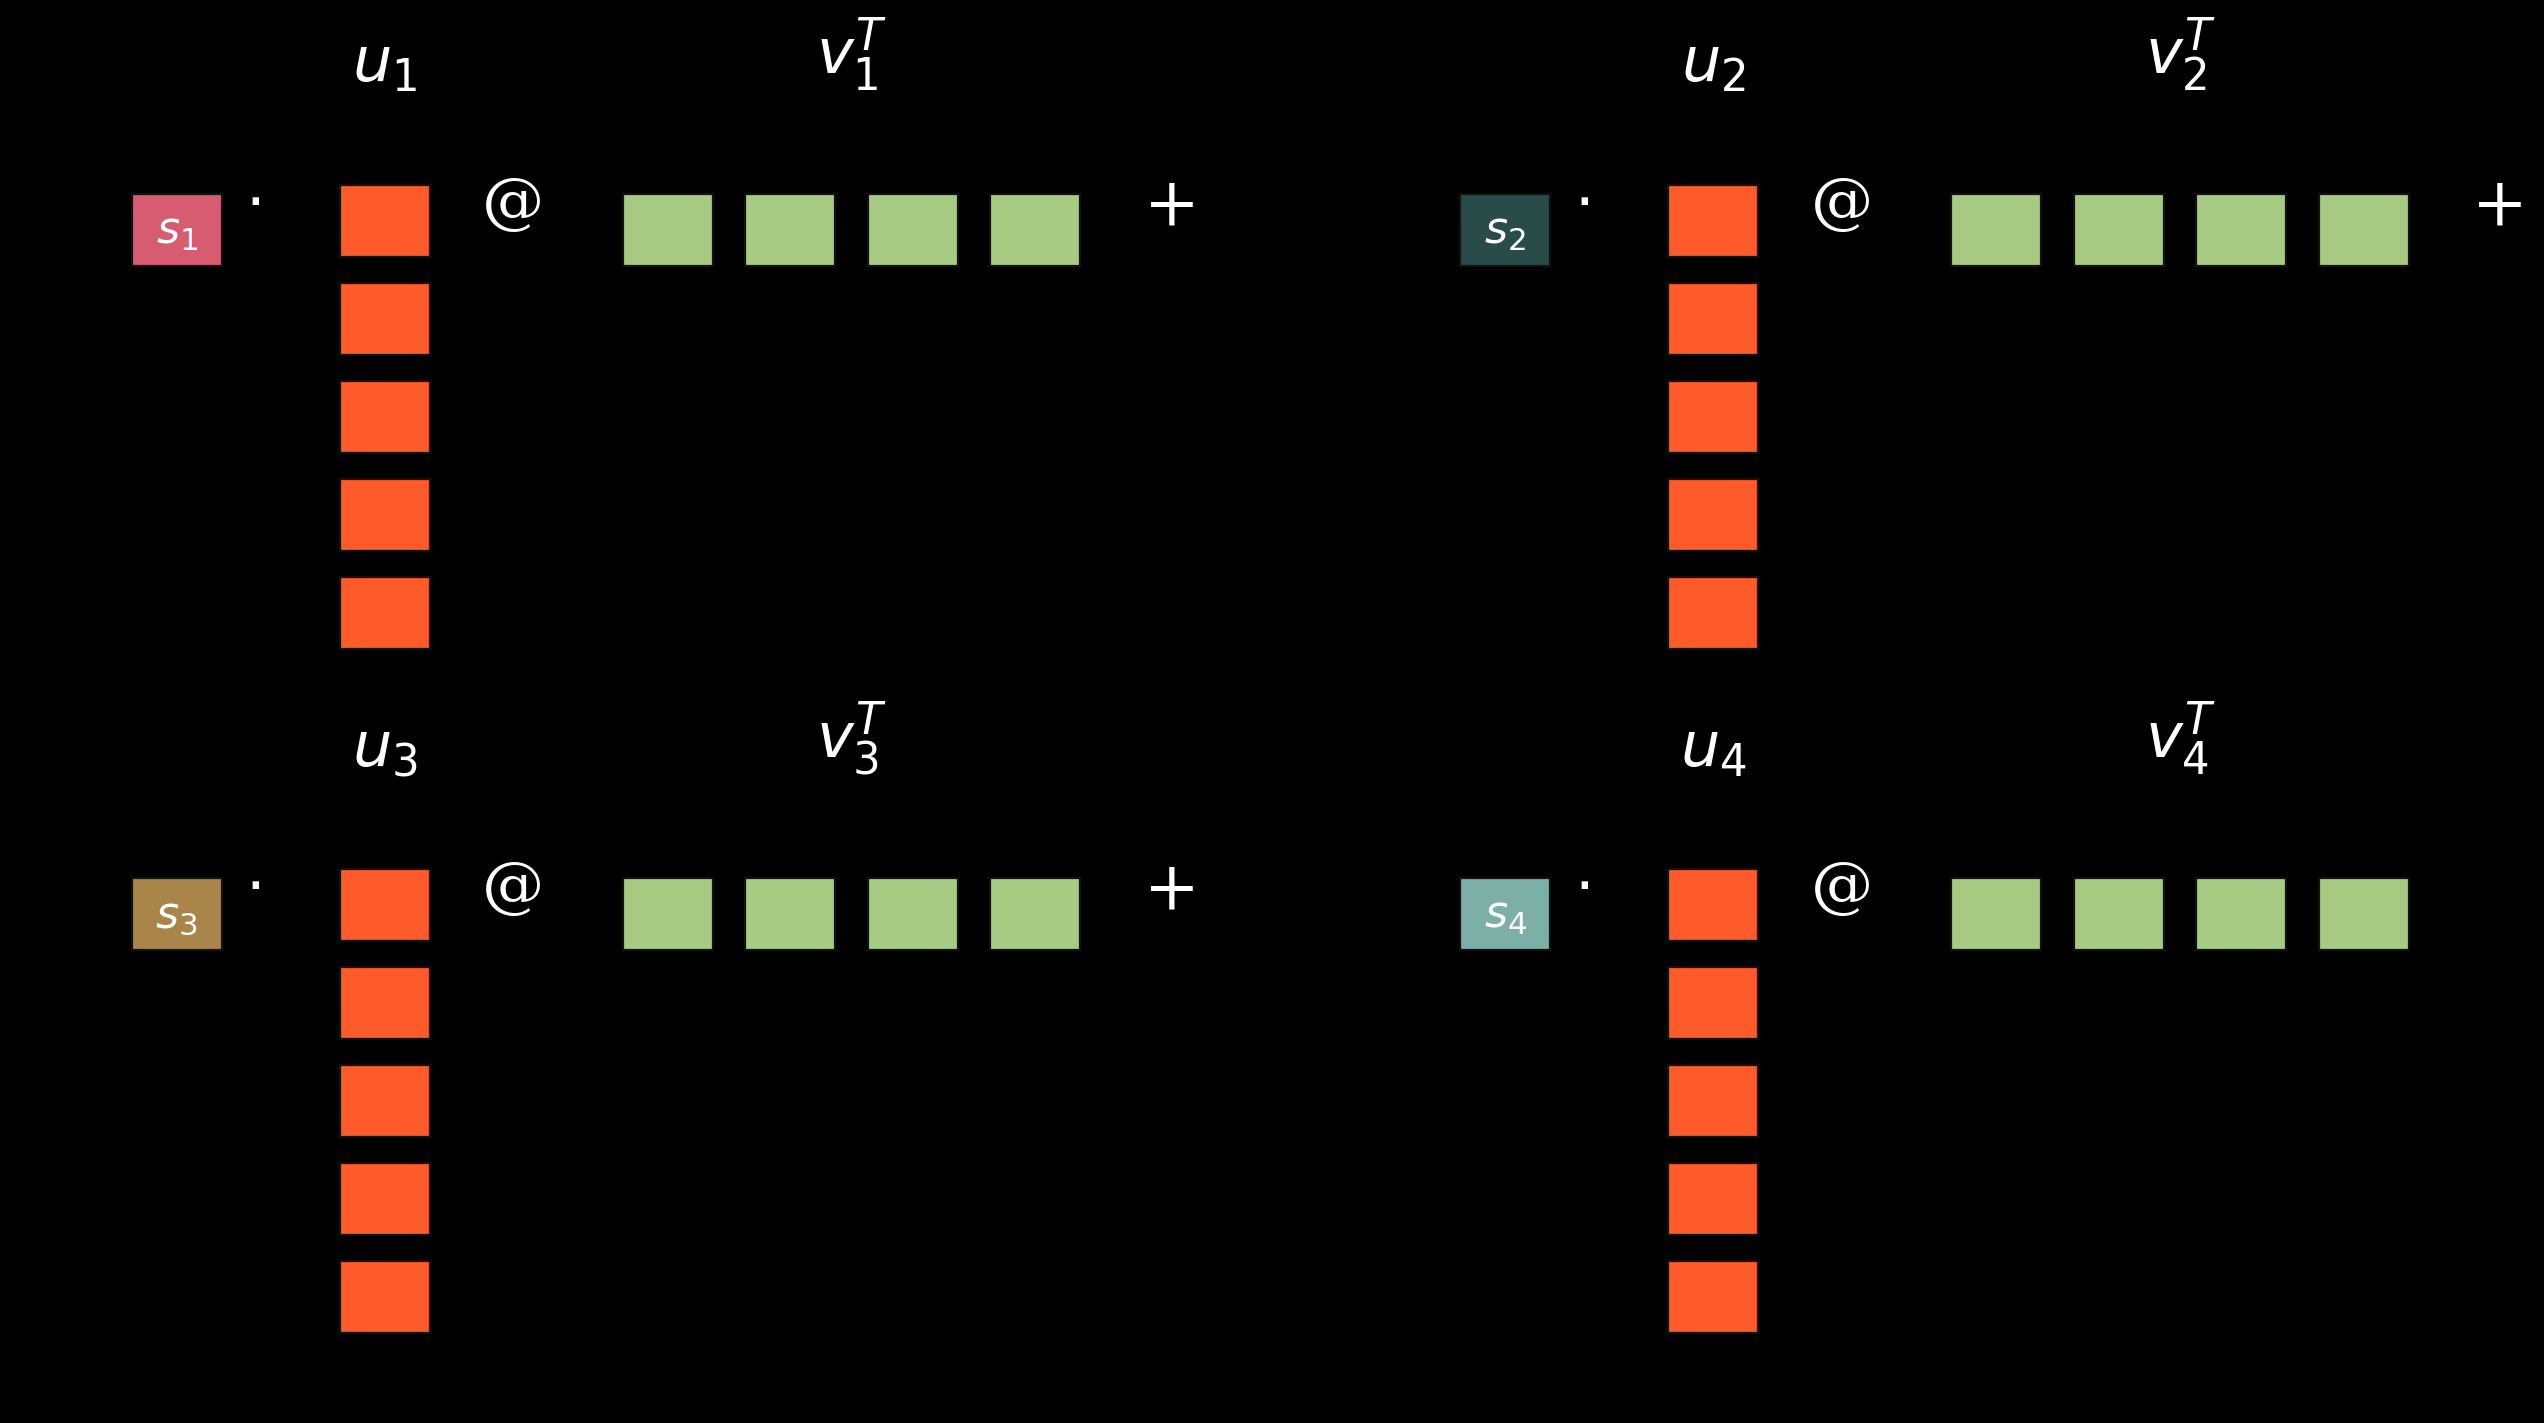

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================
# 参数
# =========================
n = 5      # u_i 的长度
D = 4      # v_i^T 的长度
r = 4      # 项数

sq = 0.78
gap = 0.28
bg = "black"

c_u = "#FF5A2A"
c_v = "#A8CB84"
sigma_colors = ["#D85C71", "#284C47", "#A9854A", "#7CAFA5"]

title_fs = 28
text_fs = 24
symbol_fs = 28

# =========================
# 基础函数
# =========================


def draw_square(ax, x, y, color, size=sq, edge="#111111", lw=1.0):
    ax.add_patch(
        Rectangle(
            (x, y), size, size,
            facecolor=color, edgecolor=edge, linewidth=lw
        )
    )


def draw_col_vector(ax, x0, y0, rows, color, size=sq, gap=gap):
    """从上到下画列向量"""
    for i in range(rows):
        y = y0 + (rows - 1 - i) * (size + gap)
        draw_square(ax, x0, y, color, size=size)


def draw_row_vector(ax, x0, y0, cols, color, size=sq, gap=gap):
    """从左到右画行向量"""
    for j in range(cols):
        x = x0 + j * (size + gap)
        draw_square(ax, x, y0, color, size=size)


def draw_sigma_box(ax, x0, y0, label, color, size=sq):
    draw_square(ax, x0, y0, color, size=size)
    ax.text(
        x0 + size / 2, y0 + size / 2, label,
        color="white", ha="center", va="center",
        fontsize=20, family="serif"
    )


# =========================
# 画图
# =========================
fig, ax = plt.subplots(figsize=(16, 9), dpi=160)
fig.patch.set_facecolor(bg)
ax.set_facecolor(bg)
ax.axis("off")

# 两列两行布局
x_left = 1.0
x_right = 12.5
y_top = 8.2
y_bot = 0.8  # 原来是 2.2，这里稍微下移，避免 u3/u4 压到方块

positions = [
    (x_left,  y_top),
    (x_right, y_top),
    (x_left,  y_bot),
    (x_right, y_bot),
]

# 每一项内部相对布局
sigma_dx = 0.0
dot_dx = 1.05
u_dx = 1.8
at_dx = 3.3
v_dx = 4.25
plus_dx = 9   # 原来 7.9，往右移一点，避免和图形重叠

for i, (x0, y0) in enumerate(positions, start=1):
    # 上方标签
    ax.text(
        x0 + u_dx + sq / 2,
        y0 + n * (sq + gap) + 0.7,   # 原来 0.55，略微抬高
        rf"$u_{{{i}}}$",
        color="white", ha="center", va="bottom",
        fontsize=title_fs, family="serif"
    )
    ax.text(
        x0 + v_dx + (D * (sq + gap) - gap) / 2,
        y0 + n * (sq + gap) + 0.7,   # 同样抬高
        rf"$v_{{{i}}}^{{T}}$",
        color="white", ha="center", va="bottom",
        fontsize=title_fs, family="serif"
    )

    # s_i 小方块
    draw_sigma_box(
        ax,
        x0 + sigma_dx,
        y0 + n * (sq + gap) - (sq + gap) - 0.1,
        rf"$s_{{{i}}}$",
        sigma_colors[i - 1]
    )

    # 点乘符号
    ax.text(
        x0 + dot_dx,
        y0 + n * (sq + gap) - 0.15,
        r"$\cdot$",
        color="white", ha="center", va="top",
        fontsize=symbol_fs, family="serif"
    )

    # u_i 列向量
    draw_col_vector(ax, x0 + u_dx, y0, n, c_u)

    # @
    ax.text(
        x0 + at_dx,
        y0 + n * (sq + gap) - 0.15,
        "@",
        color="white", ha="center", va="top",
        fontsize=symbol_fs, family="serif"
    )

    # v_i^T 行向量
    draw_row_vector(
        ax,
        x0 + v_dx,
        y0 + n * (sq + gap) - (sq + gap) - 0.1,
        D,
        c_v
    )

    # 加号（前三项后面画）
    if i in [1, 2, 3]:
        ax.text(
            x0 + plus_dx,
            y0 + n * (sq + gap) - 0.15,
            "+",
            color="white", ha="center", va="top",
            fontsize=symbol_fs + 2, family="serif"
        )

# 画布范围
ax.set_xlim(0, 21.5)
ax.set_ylim(0, 14.2)

plt.tight_layout()
plt.show()

# 如需保存，取消下面注释
# plt.savefig("svd_rank1_sum.png", dpi=300, facecolor=bg, bbox_inches="tight")

## 例子

图像的奇异值分解


image shape = (500, 500)
k    rel_error      parameters
--------------------------------
5   0.201820       5005
20  0.104151       20020
50  0.058932       50050
75  0.041544       75075
100 0.030387       100100


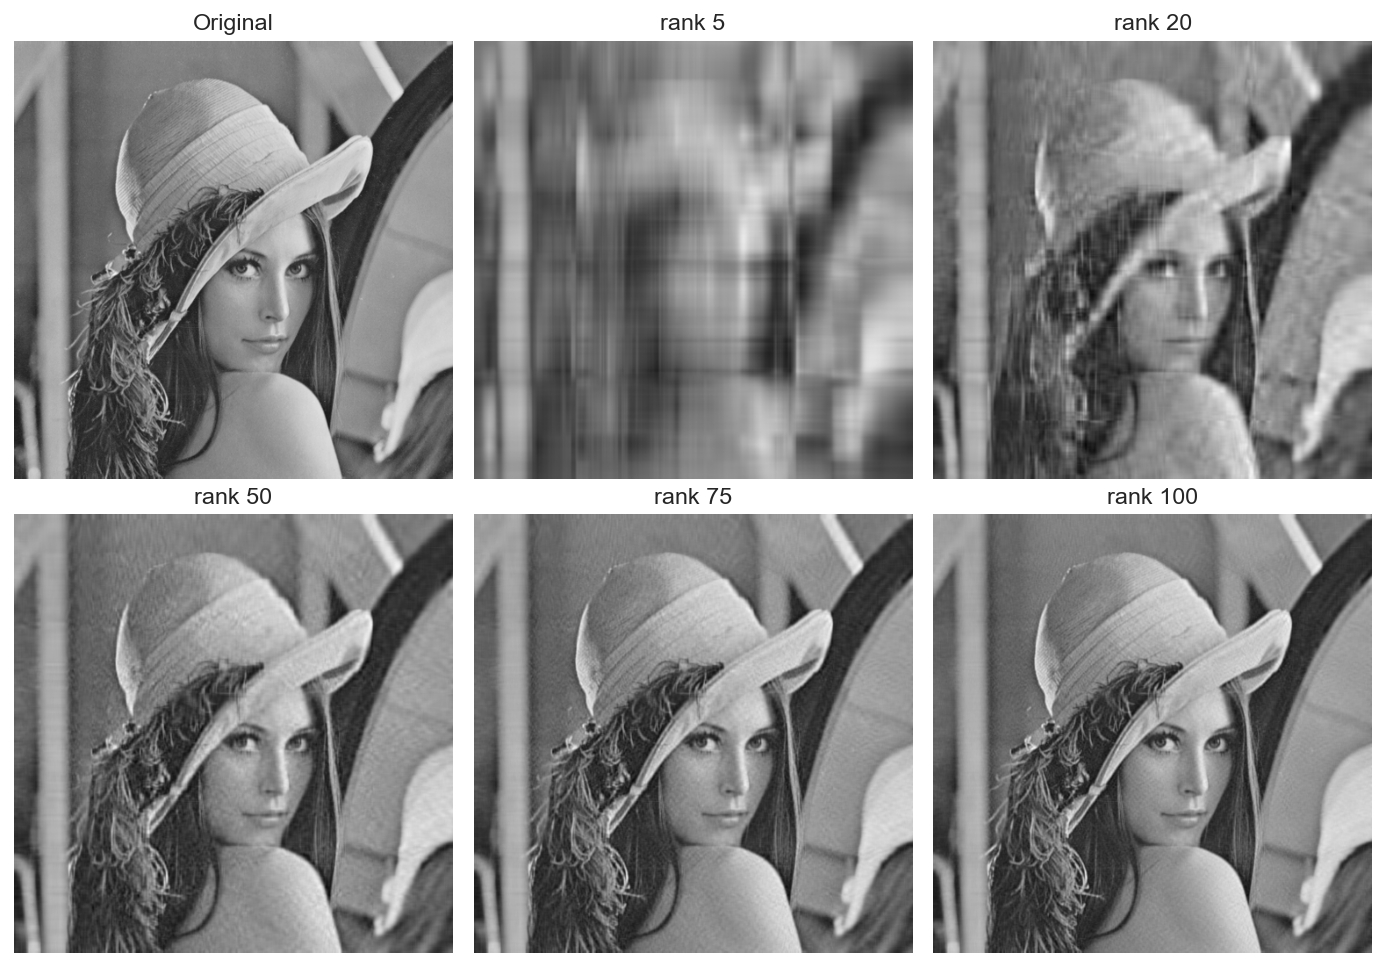

In [10]:
img_path = Path("Lenna.png")
img = np.asarray(Image.open(img_path).convert("L"), dtype=float) / 255.0

U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)


def svd_rank_k(k: int):
    return (U_img[:, :k] * s_img[:k]) @ Vt_img[:k, :]


ks = [5, 20, 50, 75, 100]
m, n = img.shape

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()

axes[0].imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title("Original")
axes[0].axis("off")

print(f"image shape = {img.shape}")
print("k    rel_error      parameters")
print("-" * 32)

for ax, k in zip(axes[1:], ks):
    img_k = svd_rank_k(k)
    rel_error = np.linalg.norm(img - img_k) / np.linalg.norm(img)
    params = m * k + k + k * n
    ax.imshow(img_k, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"rank {k}")
    ax.axis("off")
    print(f"{k:<4}{rel_error:<15.6f}{params}")

plt.tight_layout()
plt.show()

## 小结

$$
A = U\Sigma V^\top
$$

给出几何分解；

$$
A_k = \sum_{i=1}^{k}\sigma_i u_i v_i^\top
$$

给出最优 low-rank 近似。后面的 MPS / TT-SVD，本质上就是不断重复这个思想。


# 量子开放系统课程汇报--张量网络：第二部分

## 张量的图表示与TT分解


### 1. 张量的图表示 (Tensor Diagrammatic Representation)

在张量网络中，我们通常使用图形化的方式来表示张量及其运算。这种表示法在张量网络中极其有用，因为它可以简化复杂的下标求和运算。

- **标量 (Scalar)**: 一个节点，没有边。
- **向量 (Vector)**: 一个节点，带有一条边。$v_i$ 表示第 $i$ 个分量。
- **矩阵 (Matrix)**: 一个节点，带有两条边。$M_{ij}$ 表示矩阵的元素。
- **高阶张量 (Higher-order Tensor)**: 一个节点，带有三条或更多条边。

**张量缩并 (Tensor Contraction)**:
两条边相连表示对相应的指标进行求和（即 Einstein 求和约定）。
例如，矩阵乘法 $C_{ik} = \sum_j A_{ij} B_{jk}$ 在图中表示为：
将张量 $A$ 的一条边与张量 $B$ 的一条边相连。

#### 图示示例

1. **内积**: 两个向量各有一条边，连接这两条边。
2. **矩阵-向量乘法**: 矩阵有两条边，向量有一条边，连接其中一条。
3. **矩阵乘法**: 两个矩阵各有两条边，连接中间相匹配的维度。


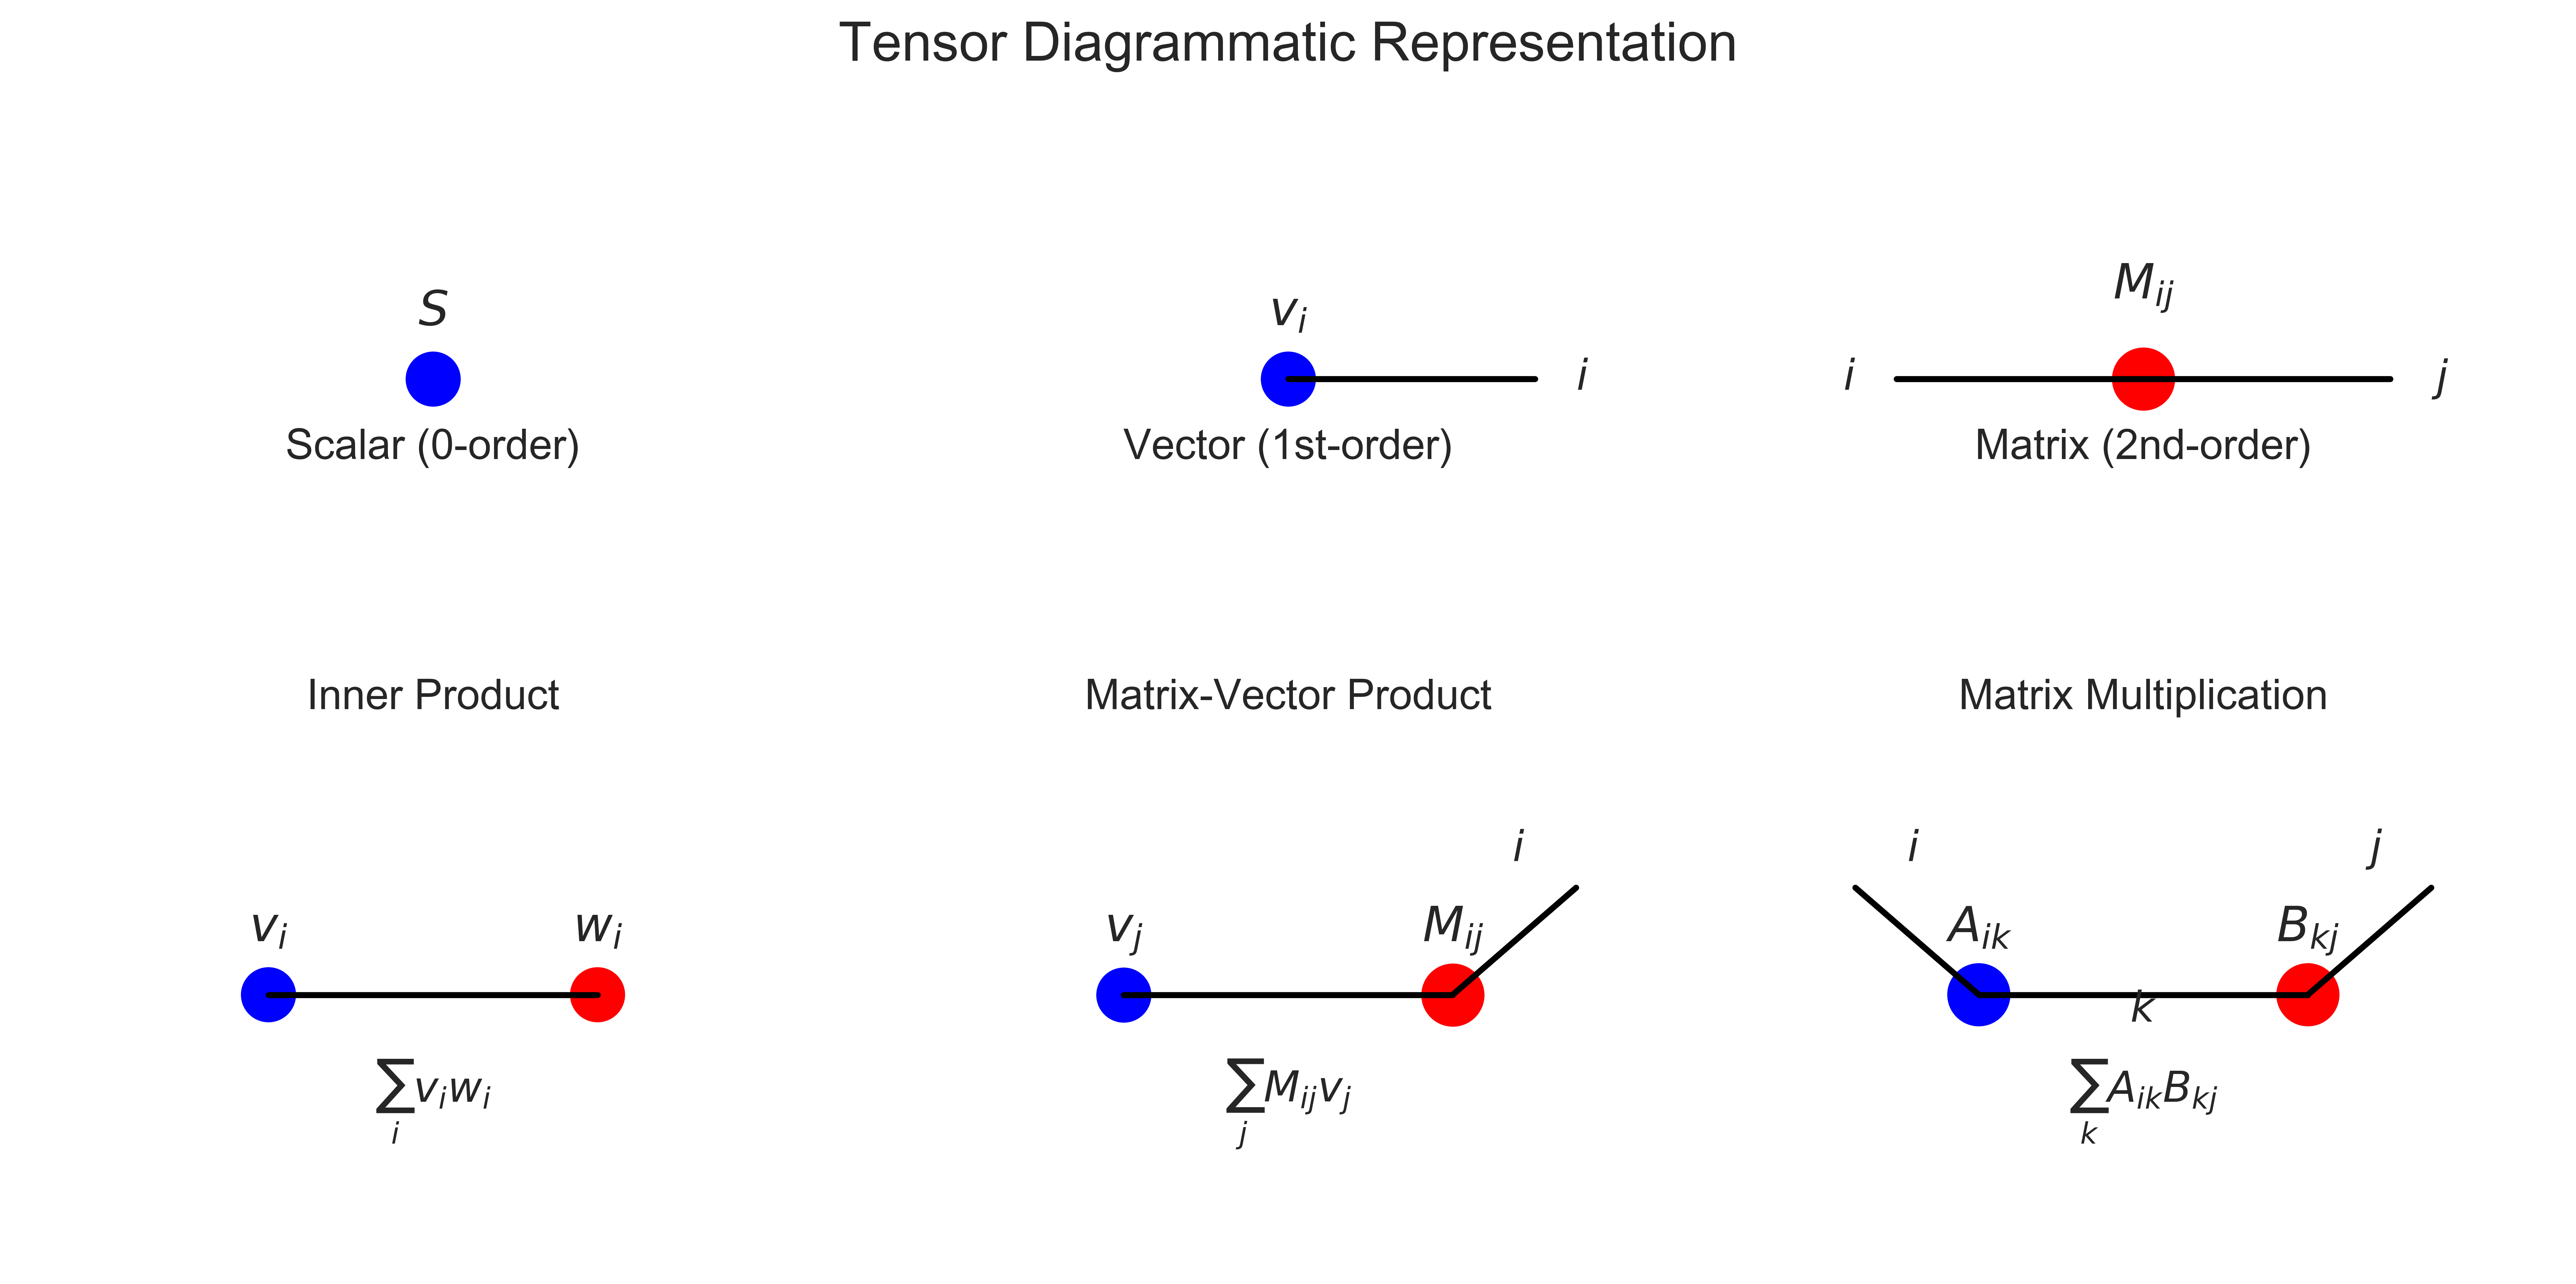

In [30]:
# Create visualizations for tensor diagrammatic representation
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=600)

# ================= 第 1 行：基本元素 =================
# 1. 标量 (Scalar)
ax = axes[0, 0]
ax.scatter([0.5], [0.5], s=300, c='blue')
ax.text(0.5, 0.6, r'$S$', fontsize=16, ha='center')
ax.text(0.5, 0.35, 'Scalar (0-order)', fontsize=14, ha='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 2. 向量 (Vector)
ax = axes[0, 1]
ax.scatter([0.5], [0.5], s=300, c='blue')
ax.plot([0.5, 0.8], [0.5, 0.5], 'k-', linewidth=2)
ax.text(0.5, 0.6, r'$v_i$', fontsize=16, ha='center')
ax.text(0.85, 0.5, r'$i$', fontsize=14, ha='left', va='center')
ax.text(0.5, 0.35, 'Vector (1st-order)', fontsize=14, ha='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 3. 矩阵 (Matrix)
ax = axes[0, 2]
ax.scatter([0.5], [0.5], s=400, c='red')
ax.plot([0.2, 0.5], [0.5, 0.5], 'k-', linewidth=2)
ax.plot([0.5, 0.8], [0.5, 0.5], 'k-', linewidth=2)
ax.text(0.5, 0.65, r'$M_{ij}$', fontsize=16, ha='center')
ax.text(0.15, 0.5, r'$i$', fontsize=14, ha='right', va='center')
ax.text(0.85, 0.5, r'$j$', fontsize=14, ha='left', va='center')
ax.text(0.5, 0.35, 'Matrix (2nd-order)', fontsize=14, ha='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# ================= 第 2 行：缩并操作 =================
# 4. 内积 (Inner product)
ax = axes[1, 0]
ax.scatter([0.3, 0.7], [0.5, 0.5], s=300, c=['blue', 'red'])
ax.plot([0.3, 0.7], [0.5, 0.5], 'k-', linewidth=2)
ax.text(0.3, 0.6, r'$v_i$', fontsize=16, ha='center')
ax.text(0.7, 0.6, r'$w_i$', fontsize=16, ha='center')
ax.text(0.5, 0.3, r'$\sum_i v_i w_i$', fontsize=14, ha='center')
ax.set_title('Inner Product', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 5. 矩阵-向量乘法
ax = axes[1, 1]
ax.scatter([0.3], [0.5], s=300, c='blue')  # vector
ax.scatter([0.7], [0.5], s=400, c='red')   # matrix
ax.plot([0.3, 0.7], [0.5, 0.5], 'k-', linewidth=2)
ax.plot([0.7, 0.85], [0.5, 0.7], 'k-', linewidth=2)
ax.text(0.3, 0.6, r'$v_j$', fontsize=16, ha='center')
ax.text(0.7, 0.6, r'$M_{ij}$', fontsize=16, ha='center')
ax.text(0.78, 0.75, r'$i$', fontsize=14, ha='center')
ax.text(0.5, 0.3, r'$\sum_j M_{ij} v_j$', fontsize=14, ha='center')
ax.set_title('Matrix-Vector Product', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 6. 矩阵乘法
ax = axes[1, 2]
ax.scatter([0.3, 0.7], [0.5, 0.5], s=400, c=['blue', 'red'])
ax.plot([0.3, 0.7], [0.5, 0.5], 'k-', linewidth=2)
ax.plot([0.3, 0.15], [0.5, 0.7], 'k-', linewidth=2)  # left
ax.plot([0.7, 0.85], [0.5, 0.7], 'k-', linewidth=2)  # right
ax.text(0.3, 0.6, r'$A_{ik}$', fontsize=16, ha='center')
ax.text(0.7, 0.6, r'$B_{kj}$', fontsize=16, ha='center')
ax.text(0.22, 0.75, r'$i$', fontsize=14, ha='center')
ax.text(0.5, 0.45, r'$k$', fontsize=14, ha='center')
ax.text(0.78, 0.75, r'$j$', fontsize=14, ha='center')
ax.text(0.5, 0.3, r'$\sum_k A_{ik} B_{kj}$', fontsize=14, ha='center')
ax.set_title('Matrix Multiplication', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.suptitle('Tensor Diagrammatic Representation', fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

### 2. Tensor-train 分解 (TT Decomposition)

#### 2.1 为什么需要 TT 分解？

考虑一个 $N$ 阶的高维张量 $T_{s_1, s_2, \ldots, s_N}$。假设每个维度的物理自由度都是 $d$，那么这个张量的总元素个数为 $d^N$。
随着维度 $N$ 的增加，存储和计算所需的资源将呈**指数级增长**，这就是著名的**维度灾难 (Curse of Dimensionality)**。

例如在量子多体物理中，一个由 $N$ 个自旋（每个自旋有 2 个状态）构成的系统，其多体波函数就是一个具有 $2^N$ 个元素的张量。当 $N$ 达到几十时，现代计算机的内存也无法直接存储这个张量。

为了打破维度灾难，我们需要一种结构化的方法来**压缩**这些高维张量。**Tensor-Train (TT) 分解** 就是其中最重要的一种。它通过一系列低阶张量（主要是三阶张量，即“核”，Core）的局部缩并，来极其高效地表达或近似一个极高阶的张量。

#### 2.2 TT 分解的基本定义

给定 $N$ 阶张量 $T_{s_1\cdots s_N}$，TT 分解将其写为一组低阶核张量的链式乘积（缩并）：

$$
T_{s_1\cdots s_N}
=\sum_{a_1,\ldots,a_{N-1}}
A^{(1)}_{s_1 a_1}A^{(2)}_{s_2 a_1 a_2}\cdots A^{(N)}_{s_N a_{N-1}}.
$$

- $s_n$：称为**物理指标 (Physical Index)**，代表原始张量的各个维度。
- $a_n$：称为**辅助指标 (Bond Index / Virtual Index)**，它们只在相邻的两个核之间共享，通过对它们求和（缩并）将这些核连接在一起。
- $r_n = \dim(a_n)$：称为 **TT 秩 (TT-Rank)**。TT 秩的大小直接决定了该分解的表达能力和所需的存储代价。

如果最大 TT 秩限制在 $r$ 以内，那么存储这 $N$ 个核张量所需的总参数量大约为 $N d r^2$，这是一个关于 $N$ 的**线性复杂度** $\mathcal{O}(N)$，从而彻底避免了 $\mathcal{O}(d^N)$ 的指数灾难！

在量子信息和凝聚态物理中，这种结构被称为**矩阵乘积态 (Matrix Product States, MPS)**。

#### 2.3 四阶张量示例与 TT 积

以一个四阶张量 $T_{s_1 s_2 s_3 s_4}$ 为例，它可以被分解为四个核：

$$
T_{s_1s_2s_3s_4}=\sum_{a_1,a_2,a_3}
A^{(1)}_{s_1a_1}A^{(2)}_{s_2a_1a_2}A^{(3)}_{s_3a_2a_3}A^{(4)}_{s_4a_3}.
$$

如果我们将辅助指标 $a_k$ 看作矩阵乘法的行和列指标，那么在给定了具体的物理指标 $s_1, s_2, s_3, s_4$ 后，上述求和就可以看作是一连串普通矩阵的连乘：

$$
T_{s_1s_2s_3s_4} = \mathbf{A}^{(1)}(s_1) \cdot \mathbf{A}^{(2)}(s_2) \cdot \mathbf{A}^{(3)}(s_3) \cdot \mathbf{A}^{(4)}(s_4)
$$

这就是为什么它在量子力学中被称为“矩阵乘积态”。

#### 2.4 计算框架：TT-SVD 算法详解

对于一个给定的稠密张量，我们如何把它转换成 TT 格式呢？最标准、最稳定的算法就是 **TT-SVD**。其核心思想是把前面讲过的截断 SVD 重复应用。

假设我们要分解四阶张量 $T_{s_1 s_2 s_3 s_4}$，算法步骤如下：

1. **第一次折叠与 SVD**:
   将张量 $T$ 的第一个指标孤立出来，视为行指标，后面的统统打包为列指标。重塑为一个大小为 $d_1 \times (d_2 d_3 d_4)$ 的大矩阵 $M_1$。
   对 $M_1$ 做 SVD: $M_1 = U_1 \Sigma_1 V_1^\top$。
   - 保留前 $r_1$ 个最大的奇异值。
   - 把 $U_1$ (大小为 $d_1 \times r_1$) 拿出来作为第一个核 $A^{(1)}$。
   - 剩余的 $\Sigma_1 V_1^\top$ (大小为 $r_1 \times d_2 d_3 d_4$) 传给下一步。

2. **第二次折叠与 SVD**:
   将上一步传下来的矩阵，将 $s_2$ 释放出来作为行，与左边传来的 $a_1$ 合并，重塑为 $(r_1 d_2) \times (d_3 d_4)$ 的矩阵 $M_2$。
   对 $M_2$ 做 SVD: $M_2 = U_2 \Sigma_2 V_2^\top$。
   - 截断保留前 $r_2$ 个奇异值。
   - 将 $U_2$ (大小为 $r_1 d_2 \times r_2$) 重新折叠成三阶张量 $A^{(2)}$ (大小为 $d_2 \times r_1 \times r_2$)。
   - 剩余的 $\Sigma_2 V_2^\top$ 传给下一步。

3. **重复此过程**:
   一直进行到倒数第二步，最后剩下的那块就自然构成了最后一个核 $A^{(N)}$。

**每次 SVD 的截断误差都是严格受控的**（由 Eckart-Young 定理保证）。只要每一步丢弃的奇异值都足够小，我们就能用极小的参数量极其精确地还原出高维张量。

#### 2.5 最优 TT 低秩近似

如果不对奇异值进行截断，TT-SVD 得到的将是一个精确分解，但此时 TT 秩 $r_k$ 会在中间暴涨（甚至可能达到 $d^{N/2}$），依然无法避开指数灾难。

为了真正实现压缩，我们通常会人为设定一个最大的截断维数（通常记作 $\chi$ 或 $D$），强制在每次 SVD 时最多只保留 $\chi$ 个奇异值，这就定义了如下的非线性优化问题：

$$
\min_{\dim(a_n)\le\chi}\|T-\tilde T\|_F
$$

TT-SVD 算法为这个极其困难的全局非线性优化问题提供了一个**非常优秀的次优解（准最优近似）**。在很多物理体系中（例如满足面积律，Area Law，的量子基态），奇异值会呈指数级衰减，此时即使取一个很小的 $\chi$（比如几十到几百），就能取得机器精度级别的逼近效果。


In [ ]:
import numpy as np

rng = np.random.default_rng(42)

# 物理维数（s1,s2,s3,s4）
d1 = d2 = d3 = d4 = 4
# 辅助维数（a1,a2,a3）
r1, r2, r3 = 3, 5, 2

A1 = rng.normal(size=(d1, r1))
A2 = rng.normal(size=(d2, r1, r2))
A3 = rng.normal(size=(d3, r2, r3))
A4 = rng.normal(size=(d4, r3))

# T[s1,s2,s3,s4] = sum_{a1,a2,a3} A1[s1,a1] A2[s2,a1,a2] A3[s3,a2,a3] A4[s4,a3]
T = np.einsum("ia,jab,kbc,lc->ijkl", A1, A2, A3, A4)


print("Step 1. 随机生成 4 个 TT 核张量（A^(1)~A^(4)）")
print(f"  A^(1) shape = {A1.shape}")
print(f"  A^(2) shape = {A2.shape}")
print(f"  A^(3) shape = {A3.shape}")
print(f"  A^(4) shape = {A4.shape}")

print("\nStep 2. 进行缩并（einsum）得到目标四阶张量 T")
print(f"  T shape      = {T.shape}")
print(f"  ||T||_F      = {np.linalg.norm(T):.4f}")

Step 1. 随机生成 4 个 TT 核张量（A^(1)~A^(4)）
  A^(1) shape = (4, 3)
  A^(2) shape = (4, 3, 5)
  A^(3) shape = (4, 5, 2)
  A^(4) shape = (4, 2)

Step 2. 进行缩并（einsum）得到目标四阶张量 T
  T shape      = (4, 4, 4, 4)
  ||T||_F      = 32.2864


In [13]:
def tt_svd(tensor, chi=None, eps=None):
    """
    TT-SVD with optional rank truncation.
    chi: 每个 bond 的最大截断维数
    eps: 相对阈值，保留 s_i > eps * s_1 的奇异值
    """
    dims = tensor.shape
    N = len(dims)
    cores = []
    ranks = [1]

    C = tensor.copy()
    r_prev = 1

    for n in range(N - 1):
        C = C.reshape(r_prev * dims[n], -1)
        U, S, Vh = np.linalg.svd(C, full_matrices=False)

        r = len(S)
        if eps is not None and len(S) > 0:
            r = min(r, int(np.sum(S > eps * S[0])))
            r = max(r, 1)
        if chi is not None:
            r = min(r, chi)

        U = U[:, :r]
        S = S[:r]
        Vh = Vh[:r, :]

        core = U.reshape(r_prev, dims[n], r)
        cores.append(core)
        ranks.append(r)

        C = np.diag(S) @ Vh
        r_prev = r

    cores.append(C.reshape(r_prev, dims[-1], 1))
    ranks.append(1)
    return cores, ranks


def tt_reconstruct(cores):
    X = cores[0]
    for n in range(1, len(cores)):
        X = np.tensordot(X, cores[n], axes=([-1], [0]))
    # (1, d1, d2, ..., dN, 1) -> (d1, d2, ..., dN)
    return np.squeeze(X, axis=(0, -1))


def tt_param_count(cores):
    return int(sum(core.size for core in cores))


rng = np.random.default_rng(2026)
T4 = rng.normal(size=(10, 10, 10, 10))
full_params = T4.size
chis = [2, 4, 8, 10, 20, 30, 40, 50, 75, 100]

print("【完全随机张量测试】")
print(f"原始张量维度: {T4.shape}")
print(f"原始参数量  : {full_params}")
print("\n逐个测试不同截断维数 chi：")
print("-" * 92)
print(f"{'chi':>5} {'TT-ranks':>20} {'rel_err':>14} {'params':>10} {'compression':>14}")
print("-" * 92)

best_rel_err = None
best_chi = None

for chi in chis:
    cores, ranks = tt_svd(T4, chi=chi)
    T4_hat = tt_reconstruct(cores)
    rel_err = np.linalg.norm(T4 - T4_hat) / np.linalg.norm(T4)
    params = tt_param_count(cores)
    compression = full_params / params

    print(f"{chi:>5d} {str(ranks):>20} {rel_err:>14.3e} {params:>10d} {compression:>13.2f}x")

    if best_rel_err is None or rel_err < best_rel_err:
        best_rel_err = rel_err
        best_chi = chi

【完全随机张量测试】
原始张量维度: (10, 10, 10, 10)
原始参数量  : 10000

逐个测试不同截断维数 chi：
--------------------------------------------------------------------------------------------
  chi             TT-ranks        rel_err     params    compression
--------------------------------------------------------------------------------------------
    2      [1, 2, 2, 2, 1]      9.906e-01        120         83.33x
    4      [1, 4, 4, 4, 1]      9.691e-01        400         25.00x
    8      [1, 8, 8, 8, 1]      8.871e-01       1440          6.94x
   10   [1, 10, 10, 10, 1]      8.260e-01       2200          4.55x
   20   [1, 10, 20, 10, 1]      6.781e-01       4200          2.38x
   30   [1, 10, 30, 10, 1]      5.452e-01       6200          1.61x
   40   [1, 10, 40, 10, 1]      4.290e-01       8200          1.22x
   50   [1, 10, 50, 10, 1]      3.234e-01      10200          0.98x
   75   [1, 10, 75, 10, 1]      1.126e-01      15200          0.66x
  100  [1, 10, 100, 10, 1]      2.871e-15      20200          0.50

In [ ]:
# 构造一个本质上是低秩的张量 (TT 秩为 4) 并加入少量噪声
r_true = 4
A1 = rng.normal(size=(10, r_true))
A2 = rng.normal(size=(10, r_true, r_true))
A3 = rng.normal(size=(10, r_true, r_true))
A4 = rng.normal(size=(10, r_true))
T4_clean = np.einsum("ia,jab,kbc,lc->ijkl", A1, A2, A3, A4)

noise = rng.normal(scale=0.5, size=(10, 10, 10, 10))
T4_lowrank = T4_clean + noise

full_params = T4_lowrank.size
chis = [2, 3, 4, 5, 6, 7, 8, 10, 20, 50, 100]

print("【带噪声的低秩张量测试】")
print(f"原始张量维度: {T4_lowrank.shape}")
print(f"原始参数量  : {full_params}")
print(f"加入噪声比例: {np.linalg.norm(noise)/np.linalg.norm(T4_clean):.3f}")
print("\n逐个测试不同截断维数 chi：")
print("-" * 92)
print(f"{'chi':>5} {'TT-ranks':>20} {'rel_err':>14} {'params':>10} {'compression':>14}")
print("-" * 92)

for chi in chis:
    cores, ranks = tt_svd(T4_lowrank, chi=chi)
    T4_hat = tt_reconstruct(cores)
    rel_err = np.linalg.norm(T4_lowrank - T4_hat) / np.linalg.norm(T4_lowrank)
    params = tt_param_count(cores)
    compression = full_params / params

    print(f"{chi:>5d} {str(ranks):>20} {rel_err:>14.3e} {params:>10d} {compression:>13.2f}x")

【带噪声的低秩张量测试】
原始张量维度: (10, 10, 10, 10)
原始参数量  : 10000
加入噪声比例: 0.066

逐个测试不同截断维数 chi：
--------------------------------------------------------------------------------------------
  chi             TT-ranks        rel_err     params    compression
--------------------------------------------------------------------------------------------
    2      [1, 2, 2, 2, 1]      7.568e-01        120         83.33x
    3      [1, 3, 3, 3, 1]      4.925e-01        240         41.67x
    4      [1, 4, 4, 4, 1]      6.460e-02        400         25.00x
    5      [1, 5, 5, 5, 1]      6.369e-02        600         16.67x
    6      [1, 6, 6, 6, 1]      6.274e-02        840         11.90x
    7      [1, 7, 7, 7, 1]      6.156e-02       1120          8.93x
    8      [1, 8, 8, 8, 1]      6.004e-02       1440          6.94x
   10   [1, 10, 10, 10, 1]      5.625e-02       2200          4.55x
   20   [1, 10, 20, 10, 1]      4.599e-02       4200          2.38x
   50   [1, 10, 50, 10, 1]      2.218e-02      102

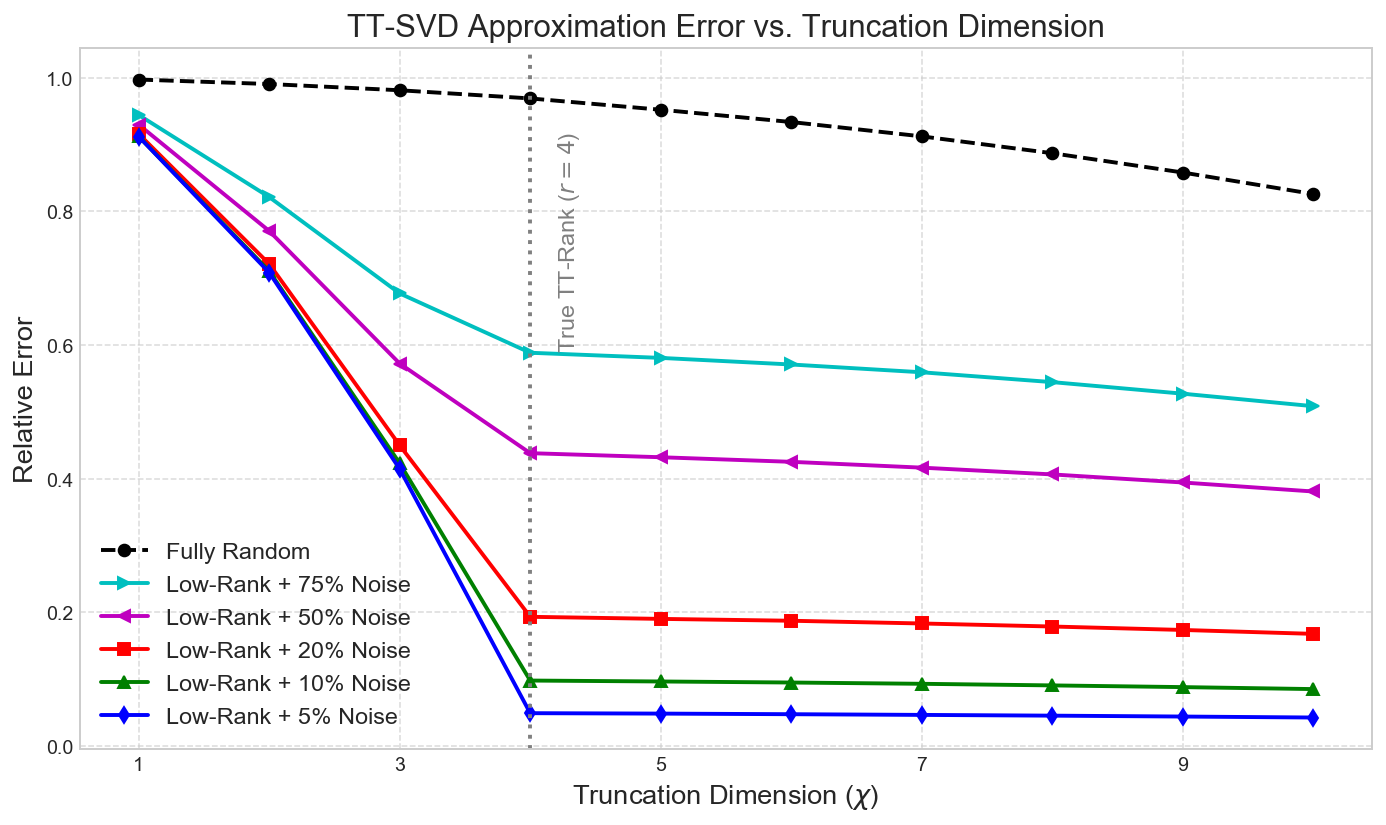

In [27]:
import matplotlib.pyplot as plt

# ==========================================
# 准备数据：比较完全随机和不同噪声强度下的表现
# ==========================================
chis_plot = np.arange(1, 11)
err_random = []
err_noise_005 = []
err_noise_010 = []
err_noise_020 = []
err_noise_050 = []
err_noise_075 = []

# 1. 完全随机张量 (与前面相同)
for chi in chis_plot:
    cores, _ = tt_svd(T4, chi=chi)
    T4_hat = tt_reconstruct(cores)
    err = np.linalg.norm(T4 - T4_hat) / np.linalg.norm(T4)
    err_random.append(err)

# 2. 构造干净的低秩张量
r_true = 4
A1 = rng.normal(size=(10, r_true))
A2 = rng.normal(size=(10, r_true, r_true))
A3 = rng.normal(size=(10, r_true, r_true))
A4 = rng.normal(size=(10, r_true))
T4_clean = np.einsum("ia,jab,kbc,lc->ijkl", A1, A2, A3, A4)
norm_clean = np.linalg.norm(T4_clean)

# 3. 生成不同强度噪声并计算误差
scales = [0.05, 0.1, 0.2, 0.5, 0.75]  # 噪声强度相对于干净张量的比例
err_lists = [err_noise_005, err_noise_010,
             err_noise_020, err_noise_050, err_noise_075]

for scale, err_list in zip(scales, err_lists):
    # 根据 scale 调整生成噪声的标准差，使其相对误差约为 scale
    noise_raw = rng.normal(size=(10, 10, 10, 10))
    noise = noise_raw * (scale * norm_clean / np.linalg.norm(noise_raw))
    T4_noisy = T4_clean + noise

    for chi in chis_plot:
        cores, _ = tt_svd(T4_noisy, chi=chi)
        T4_hat = tt_reconstruct(cores)
        err = np.linalg.norm(T4_noisy - T4_hat) / np.linalg.norm(T4_noisy)
        err_list.append(err)

# ==========================================
# 画图
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(chis_plot, err_random, 'k--o', linewidth=2, label='Fully Random')

ax.plot(chis_plot, err_noise_075, 'c->',
        linewidth=2, label='Low-Rank + 75% Noise')
ax.plot(chis_plot, err_noise_050, 'm-<',
        linewidth=2, label='Low-Rank + 50% Noise')
ax.plot(chis_plot, err_noise_020, 'r-s',
        linewidth=2, label='Low-Rank + 20% Noise')
ax.plot(chis_plot, err_noise_010, 'g-^',
        linewidth=2, label='Low-Rank + 10% Noise')
ax.plot(chis_plot, err_noise_005, 'b-d',
        linewidth=2, label='Low-Rank + 5% Noise')


# 标记真实 TT 秩
ax.axvline(x=4, color='gray', linestyle=':', linewidth=2)
ax.text(4.2, 0.6, 'True TT-Rank ($r=4$)',
        color='gray', fontsize=12, rotation=90)

ax.set_xlabel(r'Truncation Dimension ($\chi$)', fontsize=14)
ax.set_ylabel('Relative Error', fontsize=14)
ax.set_title('TT-SVD Approximation Error vs. Truncation Dimension', fontsize=16)
ax.set_xticks(np.arange(1, 11, 2))
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

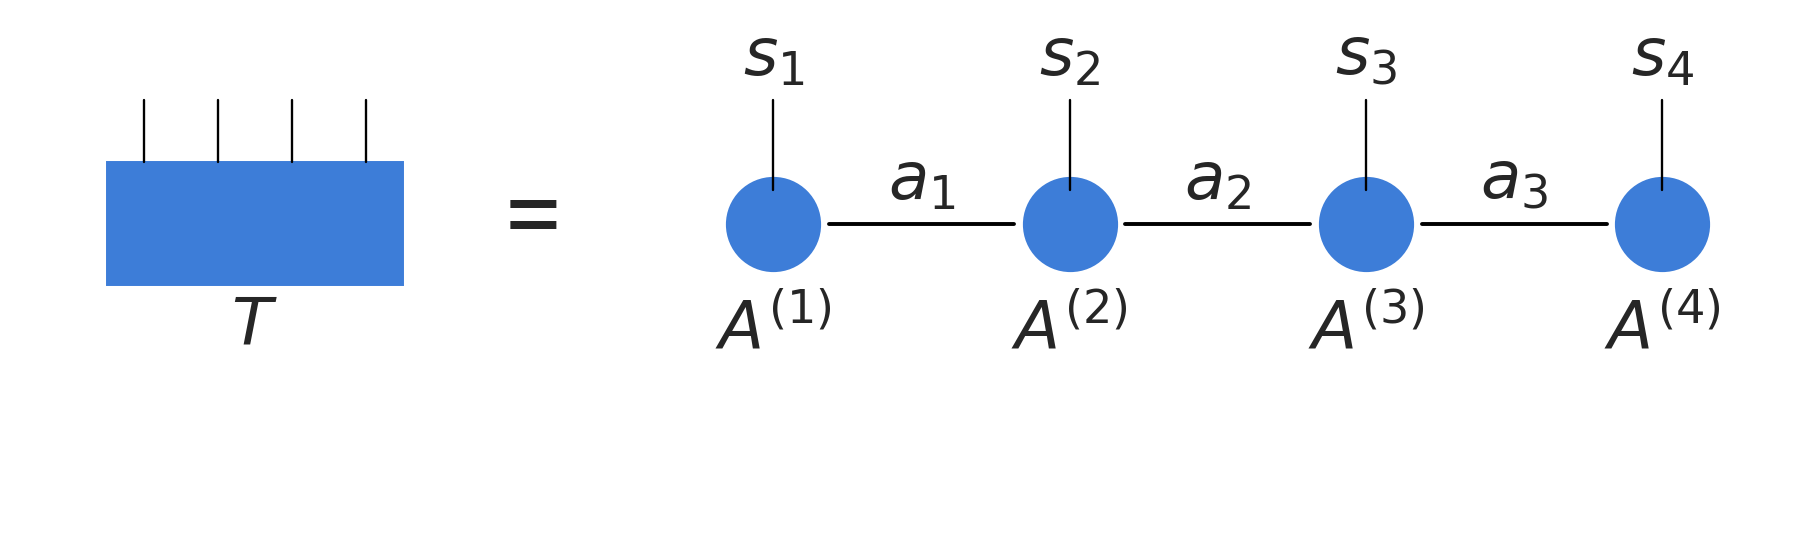

In [15]:

from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(13, 4))

node_color = "#3d7dd8"

# 左侧原始四阶张量节点 T（纯色长方形）
xT, yT = 0.16, 0.52
rect_w, rect_h = 0.16, 0.20
rect_left = Rectangle((xT - rect_w / 2, yT - rect_h / 2),
                      rect_w, rect_h, facecolor=node_color, edgecolor=node_color)


# T 的四条物理腿
for dx in [-0.06, -0.02, 0.02, 0.06]:
    ax.plot([xT + dx, xT + dx], [yT + rect_h / 2, yT + 0.20],
            "k-", linewidth=1.2, zorder=100)
ax.add_patch(rect_left)
ax.text(xT, yT - 0.12, r"$T$", fontsize=34, ha="center", va="top")


ax.text(0.31, 0.52, "=", fontsize=50, ha="center", va="center")

# 右侧四个 TT 核（圆形单色）
core_x = [0.44, 0.60, 0.76, 0.92]
core_y = 0.52


# 物理腿 s1~s4
for i, x in enumerate(core_x, start=1):
    ax.plot([x, x], [core_y + 0.055, core_y + 0.20], "k-", linewidth=1.2)
    ax.text(x, core_y + 0.22, rf"$s_{i}$",
            fontsize=34, ha="center", va="bottom")
    ax.text(x, core_y - 0.12, rf"$A^{{({i})}}$",
            fontsize=34, ha="center", va="top")

# bond 连线与 a1,a2,a3（与示例统一：'k-' + linewidth=2）
for i in range(3):
    x1, x2 = core_x[i], core_x[i + 1]
    ax.plot([x1 + 0.03, x2 - 0.03], [core_y, core_y], "k-", linewidth=2)
    ax.text((x1 + x2) / 2, core_y + 0.04,
            rf"$a_{i+1}$", fontsize=34, ha="center")

ax.scatter(core_x, [core_y] * 4, s=2300, c=node_color)

ax.set_xlim(0.03, 0.99)
ax.set_ylim(0.02, 0.86)
ax.axis("off")
plt.tight_layout()
plt.show()